# NB07 — Signal/Pulse: Executive Synthesis
**Signal/Pulse · Portfolio Capstone · Public**

This notebook serves two purposes:
1. **Narrative synthesis** — presents all four findings in sequence
2. **Asset generator** — pre-computes CSVs and PNGs consumed by `streamlit_app.py`

All charts read from `../outputs/` where possible (produced by NB04–NB06).
Live DB queries are used only for headline numbers and data not already exported.

**Run order:** NB04 → NB05 → NB06 → NB07 → streamlit_app.py

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.image import imread
from IPython.display import display, Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.schema import get_connection, DB_PATH
from src.viz import apply_style, tight

apply_style()

# ── Palette (mirrors streamlit_app.py) ───────────────────────────────────
C_SKIN    = '#4A90B8'   # calm blue
C_COSM    = '#C4627A'   # dusty rose
C_INGR    = '#5B8C6E'   # sage green
C_KOREAN  = '#D4785C'   # terracotta
C_GOLD    = '#B8965A'   # annotation gold
C_NEUTRAL = '#78909C'

# ── Paths ─────────────────────────────────────────────────────────────────
OUTPUTS = Path('../outputs')
DATA    = Path('../data')
OUTPUTS.mkdir(exist_ok=True)

# ── DB connection ─────────────────────────────────────────────────────────
try:
    conn.execute('SELECT 1')
except Exception:
    conn = get_connection()

# ── Tier helpers (CANON pattern) ──────────────────────────────────────────
CANON      = "COALESCE(p.tier_predicted, p.tier_override, c.tier)"
SKIN_TIERS = ("'skincare','mass_skincare','sensitive_skincare',"
              "'prestige_skincare','sun_protection','dermo_skincare'")
COSM_TIERS = "'cosmetics','mass_cosmetics','prestige_cosmetics','base_makeup'"
ALL_TIERS  = SKIN_TIERS + ',' + COSM_TIERS

# ── Asset check ───────────────────────────────────────────────────────────
REQUIRED_INPUTS = [
    'nb05_slope_chart.png',
    'nb05_trends_shift.png',
    'nb06_cosine_similarity.png',
    'nb06_emerging_terms.png',
    'nb06_blockc_treemap.png',
    'nb06_umap.png',
]

GENERATED_OUTPUTS = [
    # Section 1
    'nb07_trends_crossover.csv',
    'nb07_ingredient_surge.csv',
    'nb07_sku_treemap.csv',
    'nb07_review_slope.csv',
    'nb07_makeup_rebound.csv',
    # Section 2
    'wordcloud_2019.png',
    'wordcloud_2020.png',
    'wordcloud_2021.png',
    'wordcloud_2022.png',
    'wordcloud_2023.png',
    'wordcloud_2024.png',
    'wordcloud_2025.png',
    'wordcloud_2026.png',
    # Section 3
    'nb07_blockc.csv',
    # umap_embedding.csv — produced by NB06, not NB07
    # YouTube CSVs — produced by NB06 Section 6, verified in Cell 23
    'nb07_language.png',
]

print('INPUT ASSETS (from NB04–NB06):')
for f in REQUIRED_INPUTS:
    status = '✓' if (OUTPUTS / f).exists() else '✗ MISSING — run upstream notebook'
    print(f'  {status}  {f}')

print()
print('OUTPUTS THIS NOTEBOOK WILL GENERATE:')
for f in GENERATED_OUTPUTS:
    status = 'exists' if (OUTPUTS / f).exists() else 'will generate'
    print(f'  [{status:<13}]  {f}')

print()
print(f'DB: {DB_PATH}')
print(f'Reviews : {conn.execute("SELECT COUNT(*) FROM reviews").fetchone()[0]:,}')
print(f'Products: {conn.execute("SELECT COUNT(*) FROM products WHERE source_id=1").fetchone()[0]:,}')

Font: Hiragino Sans ✓
INPUT ASSETS (from NB04–NB06):
  ✓  nb05_slope_chart.png
  ✓  nb05_trends_shift.png
  ✓  nb06_cosine_similarity.png
  ✓  nb06_emerging_terms.png
  ✓  nb06_blockc_treemap.png
  ✓  nb06_umap.png

OUTPUTS THIS NOTEBOOK WILL GENERATE:
  [exists       ]  nb07_trends_crossover.csv
  [exists       ]  nb07_ingredient_surge.csv
  [exists       ]  nb07_sku_treemap.csv
  [exists       ]  nb07_review_slope.csv
  [exists       ]  nb07_makeup_rebound.csv
  [exists       ]  wordcloud_2019.png
  [exists       ]  wordcloud_2020.png
  [exists       ]  wordcloud_2021.png
  [exists       ]  wordcloud_2022.png
  [exists       ]  wordcloud_2023.png
  [exists       ]  wordcloud_2024.png
  [exists       ]  wordcloud_2025.png
  [exists       ]  wordcloud_2026.png
  [exists       ]  nb07_blockc.csv
  [exists       ]  nb07_language.png

DB: /Users/stanleyshi/Library/CloudStorage/OneDrive-Personal/Desktop/VSCode_Projects/6. Beauty_ConsumerPulse/data/signal_pulse.db
Reviews : 46,634
Products:

## CELL 1A

## 1. The Shift

Multiple independent commercial signals point the same direction: skincare
gained priority over cosmetics in Japanese beauty post-COVID. The @cosme +
Amazon review corpus, Rakuten's SKU catalogue, and Google Trends search demand
each show the structural shift — different methodologies, different platforms,
different data owners. The argument is the convergence of directional signals,
not a single decisive metric. Google Trends shows the head terms スキンケア and
化粧品 reaching parity, not a clean overtake (see Finding 1).

## CELL 1B (code) — Headline numbers

In [2]:
# ── Headline numbers — live from DB ──────────────────────────────────────
import datetime

# Defensible signals: anchored search decline + Rakuten shelf share.
# Cosmetics search decline over FULL calendar years (drop the partial current year).
_years = [r[0] for r in conn.execute(
    "SELECT DISTINCT week_year FROM trends_weekly "
    "WHERE term_group='block_B' AND term='化粧品' ORDER BY week_year").fetchall()]
_first, _last = _years[0], _years[-1]
if _last == datetime.date.today().year:
    _last = _years[-2]

cosm_decline = conn.execute(f"""
    WITH annual AS (
        SELECT week_year, AVG(interest) AS cosm
        FROM trends_weekly
        WHERE term_group = 'block_B' AND term = '化粧品'
          AND week_year IN ({_first}, {_last})
        GROUP BY week_year
    )
    SELECT ROUND(100.0 * (
        (SELECT cosm FROM annual WHERE week_year = {_last}) -
        (SELECT cosm FROM annual WHERE week_year = {_first})
    ) / (SELECT cosm FROM annual WHERE week_year = {_first}), 0)
""").fetchone()[0]

skin_skus = conn.execute(f"""
    SELECT COUNT(*) FROM products p
    JOIN categories c ON p.category_id = c.category_id
    WHERE p.source_id = 1 AND {CANON} IN ({SKIN_TIERS})
""").fetchone()[0]
cosm_skus = conn.execute(f"""
    SELECT COUNT(*) FROM products p
    JOIN categories c ON p.category_id = c.category_id
    WHERE p.source_id = 1 AND {CANON} IN ({COSM_TIERS})
""").fetchone()[0]
sku_ratio = round(skin_skus / cosm_skus, 1)

# Excluded metric (diagnostic only) — @cosme review-volume share / YoY.
# Surfaced for transparency, NOT used as a shift metric: tier share tracks the
# count of categories scraped per tier, not the market (METHODOLOGY.md Revision 2, NB05 §1).
mkt_2025 = conn.execute(f"""
    SELECT ROUND(100.0 * SUM(CASE WHEN {CANON} IN ({SKIN_TIERS})
        THEN 1 ELSE 0 END) / COUNT(*), 1)
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year = {_last} AND {CANON} IN ({ALL_TIERS})
""").fetchone()[0]
covid_jump = conn.execute(f"""
    WITH yr AS (
        SELECT r.review_year, COUNT(*) AS n
        FROM reviews r
        JOIN products p   ON r.product_id  = p.product_id
        JOIN categories c ON p.category_id = c.category_id
        WHERE {CANON} IN ({SKIN_TIERS}) AND r.review_year IN (2019, 2020)
        GROUP BY r.review_year
    )
    SELECT ROUND(100.0 * (MAX(n) - MIN(n)) / MIN(n), 1) FROM yr
""").fetchone()[0]

print('THE SHIFT — HEADLINE NUMBERS')
print('=' * 52)
print(f'  Cosmetics search decline {_first}→{_last} : {cosm_decline:+.0f}%   (anchored block_B; no crossover)')
print(f'  Rakuten SKU ratio (shelf share)   : {sku_ratio}x   ({skin_skus:,} vs {cosm_skus:,} SKUs)')
print()
print('  Excluded — scraping-coverage diagnostic, not a shift metric:')
print(f'    @cosme review share {_last}          : {mkt_2025}%   (tracks categories scraped, not the market)')
print(f'    review-volume YoY 2019→2020       : +{covid_jump}%   (corpus growth, not demand)')

# ── Export full in-scope SKU counts for the dashboard KPI ─────────────────
# The treemap CSV (nb07_sku_treemap) excludes beauty_all-categorised products,
# so summing it understates the catalogue (4.0x vs 3.7x). The dashboard reads
# these full ALL_TIERS counts so its shelf-share KPI matches this headline.
_headline_df = pd.DataFrame({'metric': ['skin_skus', 'cosm_skus'],
                             'value':  [skin_skus, cosm_skus]})
for _dst in (OUTPUTS / 'nb07_headline.csv',
             Path('../dashboard/assets') / 'nb07_headline.csv'):
    _headline_df.to_csv(_dst, index=False, encoding='utf-8-sig')
print(f'\nSaved → nb07_headline.csv  (skin_skus={skin_skus:,}, cosm_skus={cosm_skus:,})')

THE SHIFT — HEADLINE NUMBERS
  Cosmetics search decline 2019→2025 : -32%   (anchored block_B; no crossover)
  Rakuten SKU ratio (shelf share)   : 3.7x   (36,032 vs 9,758 SKUs)

  Excluded — scraping-coverage diagnostic, not a shift metric:
    @cosme review share 2025          : 69.8%   (tracks categories scraped, not the market)
    review-volume YoY 2019→2020       : +127.0%   (corpus growth, not demand)

Saved → nb07_headline.csv  (skin_skus=36,032, cosm_skus=9,758)


## CELL 1C (code) — Export: Google Trends crossover data

In [3]:
# ── nb07_trends_crossover.csv ─────────────────────────────────────────────
# Uses block_B (ANCHORED) — the only block where スキンケア and 化粧品 are on a
# shared, cross-term-comparable scale. block_A is unanchored (each term
# normalised to its own peak) and cannot support a スキンケア-vs-化粧品 read.
# (Methodology audit Revision 3, Issue 4.)
df_crossover = pd.read_sql("""
    SELECT week_start, term, interest
    FROM trends_weekly
    WHERE term_group = 'block_B'
      AND term IN ('スキンケア', '化粧品')
    ORDER BY week_start, term
""", conn)

df_crossover['week_start'] = pd.to_datetime(df_crossover['week_start'])

out = OUTPUTS / 'nb07_trends_crossover.csv'
df_crossover.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print(f'  Rows: {len(df_crossover):,}')
print(f'  Date range: {df_crossover.week_start.min().date()} → '
      f'{df_crossover.week_start.max().date()}')
print(f'  Terms: {df_crossover.term.unique().tolist()}')

Saved → nb07_trends_crossover.csv
  Rows: 180
  Date range: 2019-01-01 → 2026-06-01
  Terms: ['スキンケア', '化粧品']


## CELL 1D (code) — Export: Ingredient surge data

In [4]:
# ── nb07_ingredient_surge.csv ────────────────────────────────────────────
# Ingredient terms from keywords.xlsx — block_A independent calls only
# block_B excluded: anchored methodology, not suitable for time-series comparison

INGREDIENT_TERMS = [
    'セラミド',
    'ナイアシンアミド',
    'レチノール',
    'ヒアルロン酸',
    'アゼライン酸',
    'エクソソーム',
    'レチナール',
    'グルタチオン',
    'トラネキサム酸',
    'ビタミンC 美容',
]

placeholders = ','.join([f"'{t}'" for t in INGREDIENT_TERMS])

df_ingredients = pd.read_sql(f"""
    SELECT week_start, term, interest
    FROM trends_weekly
    WHERE term_group = 'block_A'
      AND term IN ({placeholders})
    ORDER BY week_start, term
""", conn)

df_ingredients['week_start'] = pd.to_datetime(df_ingredients['week_start'])

out = OUTPUTS / 'nb07_ingredient_surge.csv'
df_ingredients.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print(f'  Rows: {len(df_ingredients):,}')
print(f'  Terms ({df_ingredients.term.nunique()}): '
      f'{sorted(df_ingredients.term.unique().tolist())}')
print(f'  Date range: {df_ingredients.week_start.min().date()} → '
      f'{df_ingredients.week_start.max().date()}')

# Sanity check — pre vs post COVID avg per term
print()
# First full calendar year vs the last, dropping any partial current year —
# the same anchors as the headline 化粧品 decline and NB05 §4, so the project
# quotes one window rather than three.
df_ingredients['year'] = df_ingredients['week_start'].dt.year
_n = df_ingredients.groupby('year')['week_start'].nunique()
_full = _n[_n >= 12].index
_Y0, _Y1 = int(_full.min()), int(_full.max())
print(f'  {_Y0} avg vs {_Y1} avg (full calendar years):')
summary = df_ingredients.groupby('term').apply(lambda d: pd.Series({
    'pre_covid':  d[d.year == _Y0]['interest'].mean().round(1),
    'post_covid': d[d.year == _Y1]['interest'].mean().round(1),
})).reset_index()
summary['delta'] = (summary['post_covid'] - summary['pre_covid']).round(1)
summary = summary.sort_values('delta', ascending=False)
print(summary.to_string(index=False))

Saved → nb07_ingredient_surge.csv
  Rows: 900
  Terms (10): ['アゼライン酸', 'エクソソーム', 'グルタチオン', 'セラミド', 'トラネキサム酸', 'ナイアシンアミド', 'ヒアルロン酸', 'ビタミンC 美容', 'レチナール', 'レチノール']
  Date range: 2019-01-01 → 2026-06-01

  Pre-COVID avg (≤2019) vs Post-COVID avg (≥2021):
    term  pre_covid  post_covid  delta
ナイアシンアミド        5.2        64.2   59.0
   レチノール       10.2        56.1   45.9
  グルタチオン       14.5        52.6   38.1
ビタミンC 美容       23.7        61.2   37.5
  アゼライン酸        0.8        35.3   34.5
 トラネキサム酸       25.7        60.0   34.3
  エクソソーム        4.8        33.6   28.8
  ヒアルロン酸       52.5        80.3   27.8
   レチナール        2.9        16.5   13.6
    セラミド       54.2        54.7    0.5


In [5]:
# ── nb07_makeup_rebound.csv ──────────────────────────────────────────────
# Makeup-category terms from block_A (each term normalised to its own peak).
# Purpose: test the mask-rebound rival hypothesis — "cosmetics search fell
# because masks hid makeup, and demand returns once masks come off."
# Per-term, own-baseline reads are exactly what unanchored data supports;
# no cross-term comparison is made here (cf. Methodological Caveat 2).
MAKEUP_TERMS = ['口紅', 'ファンデーション', 'アイシャドウ']
placeholders = ','.join([f"'{t}'" for t in MAKEUP_TERMS])

df_makeup = pd.read_sql(f"""
    SELECT week_start, term, interest
    FROM trends_weekly
    WHERE term_group = 'block_A'
      AND term IN ({placeholders})
    ORDER BY week_start, term
""", conn)
df_makeup['week_start'] = pd.to_datetime(df_makeup['week_start'])

out = OUTPUTS / 'nb07_makeup_rebound.csv'
df_makeup.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print(f'  Rows: {len(df_makeup):,}')

# Rebound test — annual means indexed to each term's own 2019 baseline
df_makeup['year'] = df_makeup['week_start'].dt.year
annual = df_makeup.groupby(['year', 'term'])['interest'].mean().unstack()
rebased = (100 * annual / annual.loc[2019]).round(0).astype(int)
print()
print('Indexed to own 2019 = 100 (mask guidance relaxed 2023-03-13):')
print(rebased.to_string())
print()
print('Read: a pure mask effect predicts a return to ~100 after 2023.')
print('Observed: no post-2023 recovery — the bump fades and decline continues,')
print('so the mask hypothesis does not explain the cosmetics decline.')

Saved → nb07_makeup_rebound.csv
  Rows: 270

Indexed to own 2019 = 100 (mask guidance relaxed 2023-03-13):
term  アイシャドウ  ファンデーション   口紅
year                       
2019     100       100  100
2020     115        80   57
2021     127        77   42
2022     128        84   45
2023     114        86   53
2024      94        74   41
2025      80        69   36
2026      74        68   35

Read: a pure mask effect predicts a return to ~100 after 2023.
Observed: no post-2023 recovery — the bump fades and decline continues,
so the mask hypothesis does not explain the cosmetics decline.


## CELL 1E (code) — Export: Rakuten SKU treemap data

In [6]:
# ── nb07_sku_treemap.csv (expanded) ──────────────────────────────────────
# avg_rating is computed over RATED SKUs only — review_avg = 0 means
# "no reviews yet", not "rated zero"; averaging zeros in produced a severe
# artifact (all_in_one displayed 2.05 vs a true rated-only ~4.54).
# Price uses the MEDIAN — Rakuten listings include ¥1 junk listings and
# ¥300k+ outliers that distort a mean.
df_sku_raw = pd.read_sql(f"""
    SELECT
        CASE WHEN {CANON} IN ({SKIN_TIERS})
             THEN 'skincare' ELSE 'cosmetics' END AS tier_group,
        c.normalized_name AS category,
        p.review_count, p.review_avg, p.price_jpy
    FROM products p
    JOIN categories c ON p.category_id = c.category_id
    WHERE p.source_id = 1
      AND {CANON} IN ({ALL_TIERS})
      AND c.normalized_name != 'beauty_all'  -- beauty_all excluded by design:
      -- NB02b sets tier_predicted on these products, but c.normalized_name
      -- remains 'beauty_all'. Showing catalog by actual category name only.
""", conn)

df_treemap = (
    df_sku_raw
    .groupby(['tier_group', 'category'])
    .apply(lambda g: pd.Series({
        'sku_count':   len(g),
        'avg_reviews': round(g['review_count'].fillna(0).mean(), 1),
        'avg_rating':  round(g.loc[g['review_avg'] > 0, 'review_avg'].mean(), 2),
        'rated_share': round((g['review_avg'] > 0).mean(), 3),
        'med_price':   round(g['price_jpy'].median(), 0),
        'min_price':   g['price_jpy'].min(),
        'max_price':   g['price_jpy'].max(),
    }))
    .reset_index()
    .astype({'sku_count': int})
    .sort_values(['tier_group', 'sku_count'], ascending=[True, False])
)

out = OUTPUTS / 'nb07_sku_treemap.csv'
df_treemap.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print()
print(df_treemap.to_string(index=False))

Saved → nb07_sku_treemap.csv

tier_group         category  sku_count  avg_reviews  avg_rating  rated_share  med_price  min_price  max_price
 cosmetics korean_cosmetics       6047          9.5        4.51        0.674     2310.0       50.0   374000.0
 cosmetics        cosmetics       3135         98.4        4.48        1.000     2300.0      110.0    41940.0
  skincare       all_in_one       9340          2.6        4.55        0.306     3432.0        1.0   334206.0
  skincare         emulsion       4273          6.1        4.59        1.000     3300.0      200.0    68000.0
  skincare   sun_protection       4130         17.7        4.56        1.000     2728.0      100.0    40205.0
  skincare    serum_essence       3542         63.5        4.57        0.975     4180.0       88.0   199584.0
  skincare       face_cream       3435         15.8        4.60        1.000     4180.0      220.0    90310.0
  skincare        face_wash       3277         19.4        4.65        1.000     2200.0   

## CELL 1F (code) — Export: Review slope data

In [7]:
# ── nb07_review_slope.csv ────────────────────────────────────────────────
df_slope = pd.read_sql(f"""
    WITH yearly_tier AS (
        SELECT
            r.review_year,
            CASE WHEN {CANON} IN ({SKIN_TIERS})
                 THEN 'skincare' ELSE 'cosmetics' END AS tier_group,
            COUNT(*) AS review_count
        FROM reviews r
        JOIN products p   ON r.product_id  = p.product_id
        JOIN categories c ON p.category_id = c.category_id
        WHERE r.review_year BETWEEN 2019 AND 2025
          AND {CANON} IN ({ALL_TIERS})
          AND c.normalized_name != 'beauty_all'  -- see Cell 12 note
        GROUP BY r.review_year, tier_group
    ),
    total_yearly AS (
        SELECT review_year, SUM(review_count) AS total
        FROM yearly_tier
        GROUP BY review_year
    )
    SELECT
        yt.review_year,
        yt.tier_group,
        yt.review_count,
        ROUND(100.0 * yt.review_count / ty.total, 1) AS share_pct
    FROM yearly_tier yt
    JOIN total_yearly ty ON yt.review_year = ty.review_year
    ORDER BY yt.review_year, yt.tier_group
""", conn)

out = OUTPUTS / 'nb07_review_slope.csv'
df_slope.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print()
print(df_slope.to_string(index=False))

Saved → nb07_review_slope.csv

 review_year tier_group  review_count  share_pct
        2019   skincare            89      100.0
        2020  cosmetics            16        7.3
        2020   skincare           202       92.7
        2021  cosmetics           111       24.6
        2021   skincare           341       75.4
        2022  cosmetics           145       15.6
        2022   skincare           783       84.4
        2023  cosmetics           589       32.6
        2023   skincare          1220       67.4
        2024  cosmetics          1646       38.6
        2024   skincare          2619       61.4
        2025  cosmetics          4252       30.2
        2025   skincare          9828       69.8


### Finding 1 — The structural shift is supported

> Multiple independent commercial signals point the same direction — different
> methodologies, platforms, and data owners:
>
> - **Cosmetics search demand** in structural decline (~a third, 2019→2025,
>   anchored block_B). The head terms スキンケア and 化粧品 reach parity, not a
>   clean overtake — the スキンケア:化粧品 ratio rises ~0.31→0.53 while 化粧品
>   leads every year.
> - **Ingredient search** up several-fold post-COVID (NB05 §4, NB06).
> - **Rakuten SKU ratio ~3.7×** skincare to cosmetics — shelf share, not sales.
>
> The argument is the convergence of directional signals, not a single decisive
> metric; the structural read is well-supported. Individual magnitudes carry the
> caveats in METHODOLOGY.md.
>
> *Excluded — @cosme review-volume share: tier share tracks the count of
> categories scraped per tier, not the market, and is not used as a shift metric
> (METHODOLOGY.md Revision 2, NB05 §1). @cosme's contribution is language, analysed in NB06.*
>
> *Precise figures are computed live in the cell above. The Google Trends read
> uses the anchored block_B series (スキンケア vs 化粧品 on a shared scale); the
> earlier unanchored block_A "2020 crossover" was retired as not cross-comparable.*

## CELL 2A (FINAL) — TF-IDF weighted word clouds, three variants

Font: /System/Library/Fonts/ヒラギノ角ゴシック W3.ttc
Loading reviews...
Reviews: 41,297
Tokenizing...
Done.

--- PUBLIC: Combined word clouds ---
Saved → ../outputs/wordcloud_2019.png


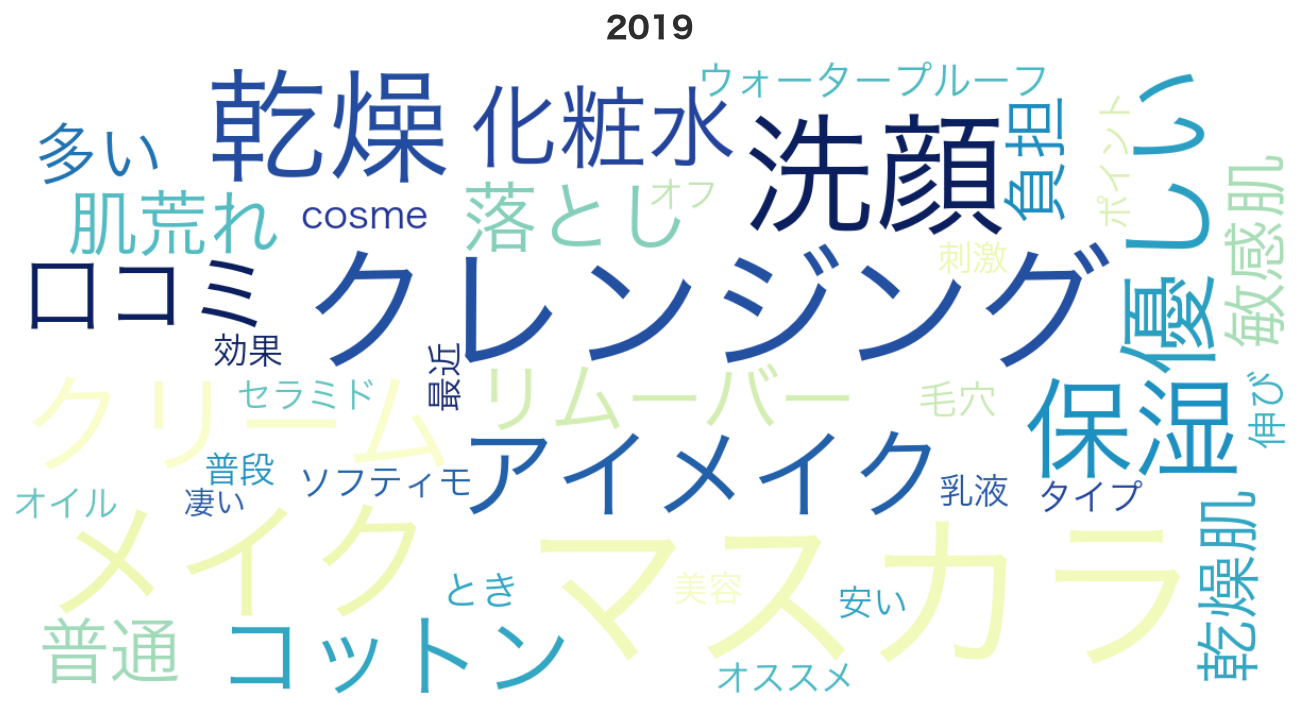

  wordcloud_2019.png  top 5: ['マスカラ', 'クレンジング', '洗顔', 'メイク', '乾燥']
Saved → ../outputs/wordcloud_2020.png


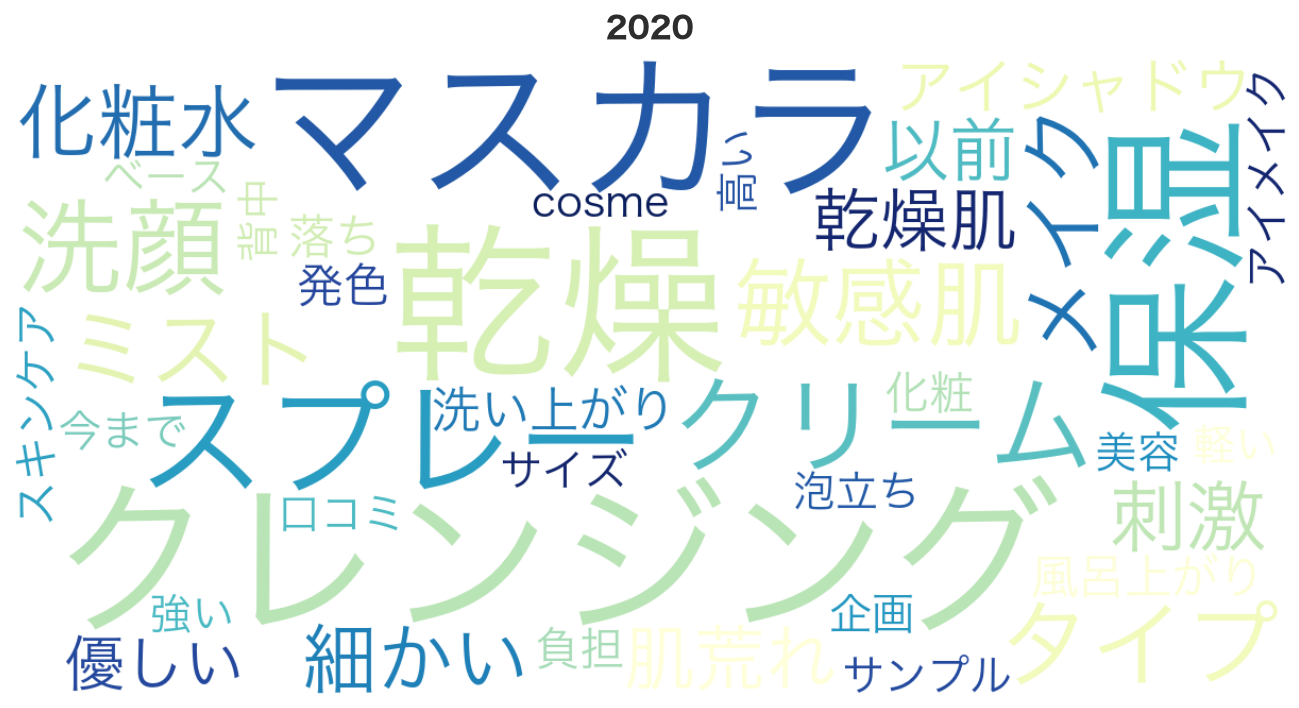

  wordcloud_2020.png  top 5: ['乾燥', 'クレンジング', '保湿', 'マスカラ', 'スプレー']
Saved → ../outputs/wordcloud_2021.png


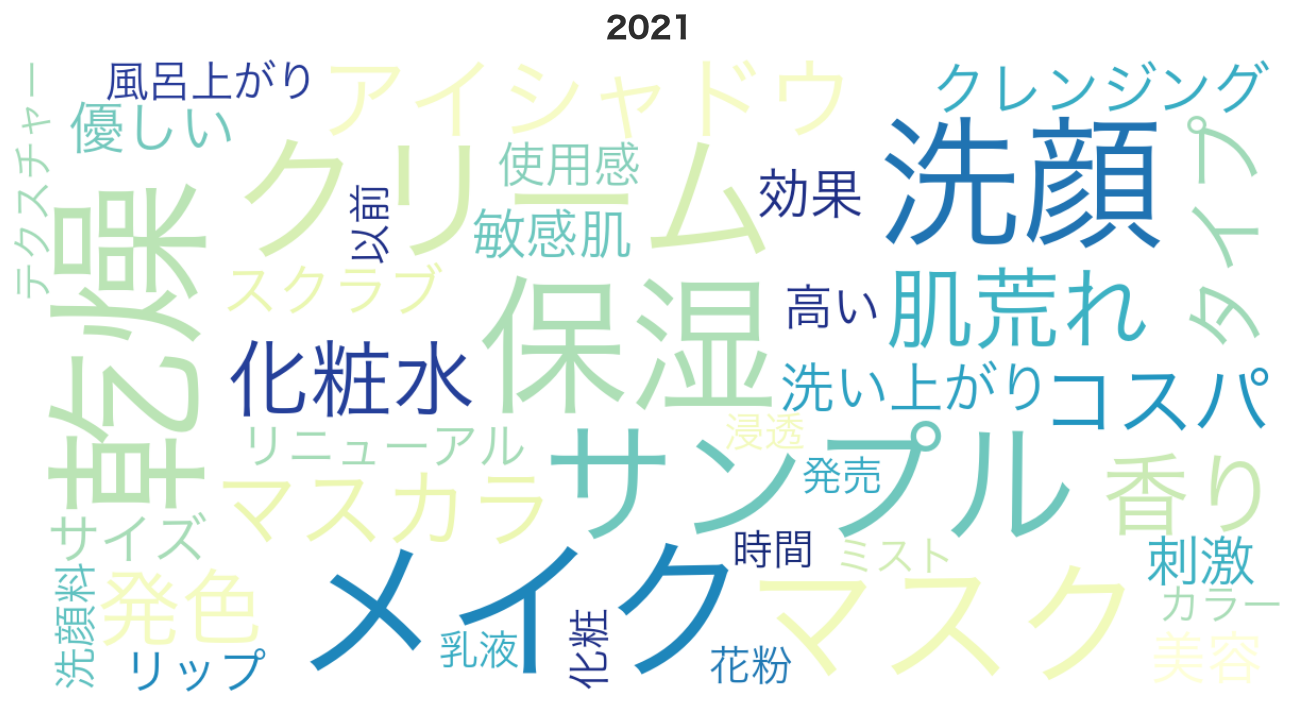

  wordcloud_2021.png  top 5: ['乾燥', 'メイク', '保湿', '洗顔', 'クリーム']
Saved → ../outputs/wordcloud_2022.png


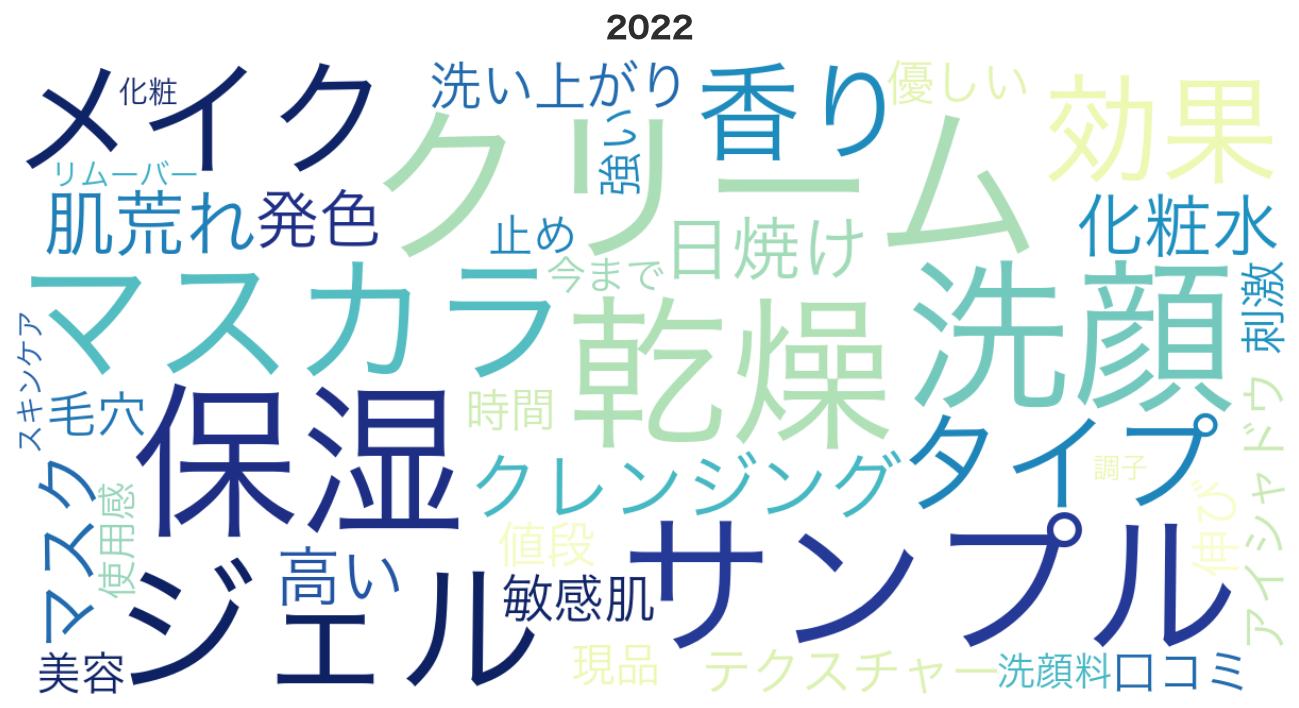

  wordcloud_2022.png  top 5: ['クリーム', '保湿', '洗顔', '乾燥', 'サンプル']
Saved → ../outputs/wordcloud_2023.png


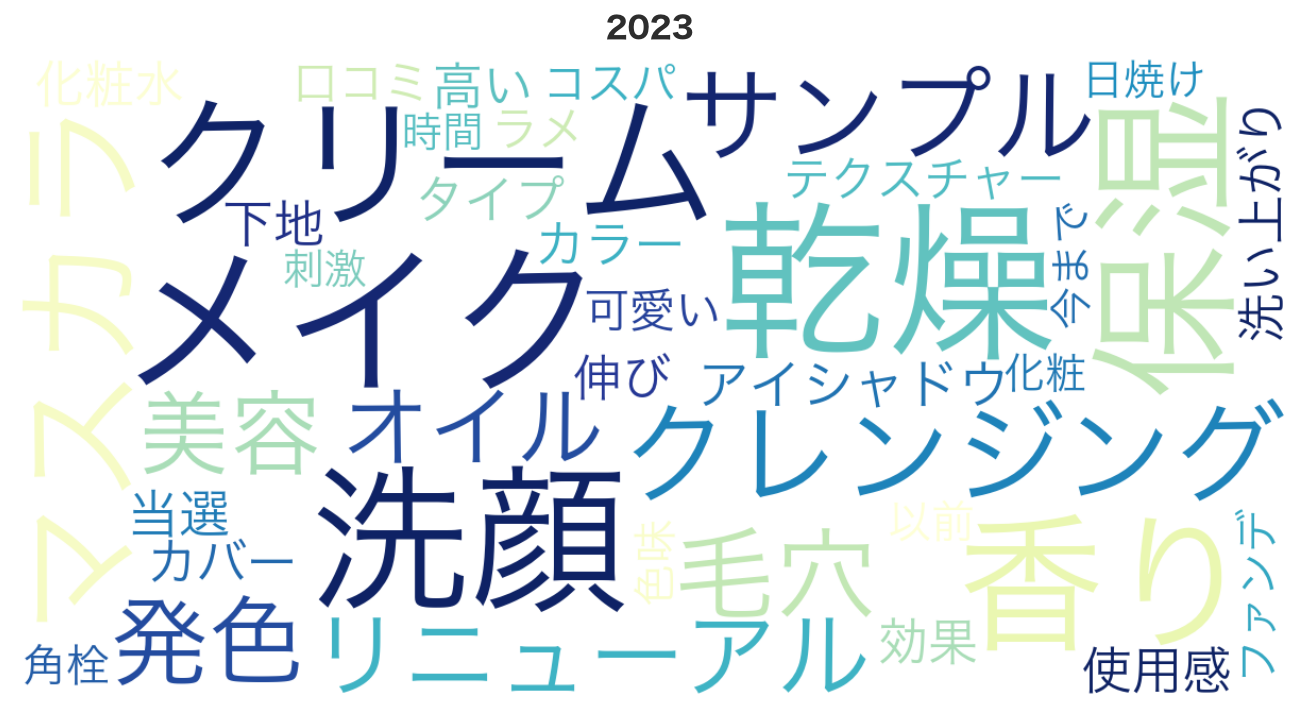

  wordcloud_2023.png  top 5: ['乾燥', 'メイク', '洗顔', '保湿', '香り']
Saved → ../outputs/wordcloud_2024.png


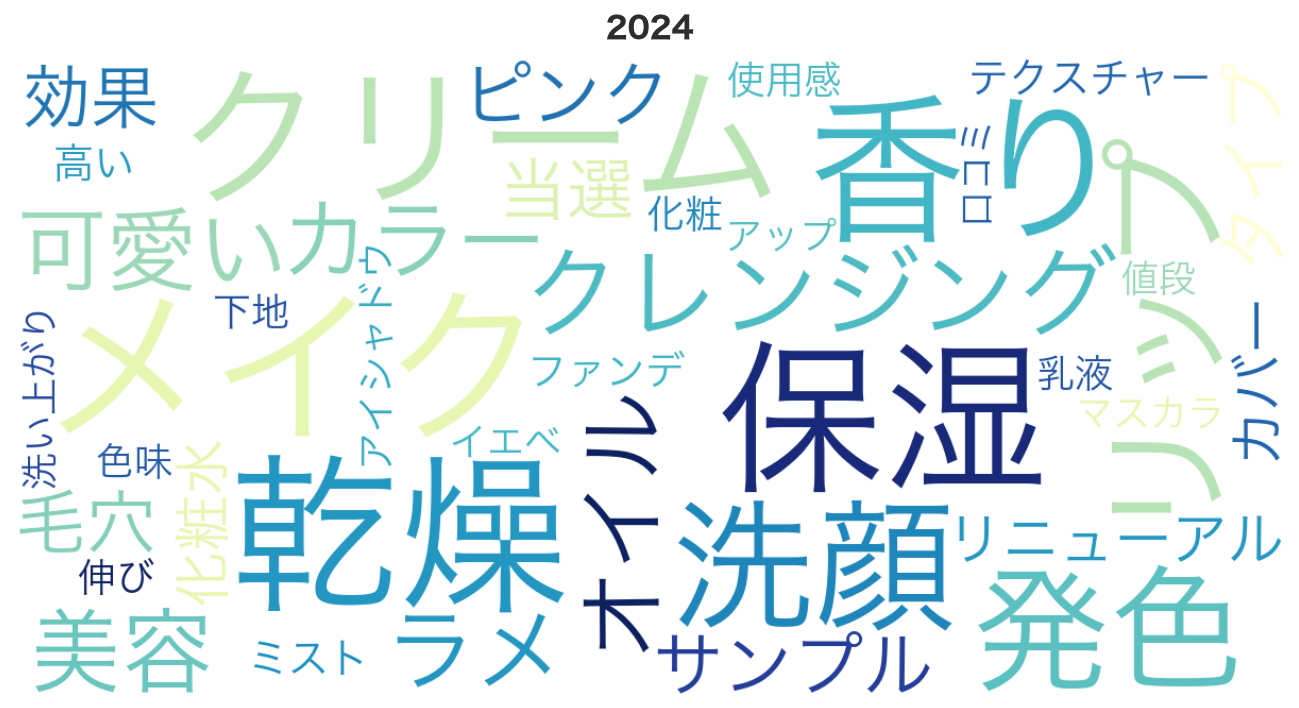

  wordcloud_2024.png  top 5: ['乾燥', 'メイク', '保湿', '香り', 'クリーム']
Saved → ../outputs/wordcloud_2025.png


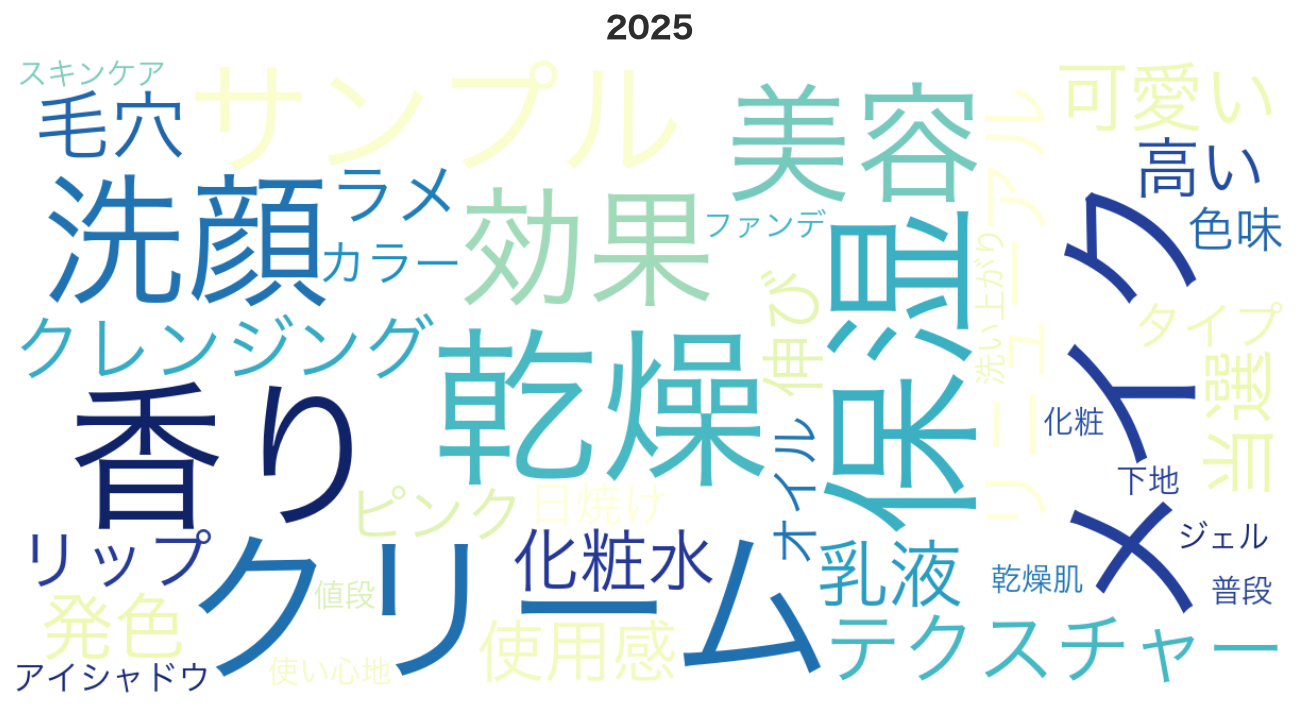

  wordcloud_2025.png  top 5: ['乾燥', '保湿', 'クリーム', '香り', 'メイク']
Saved → ../outputs/wordcloud_2026.png


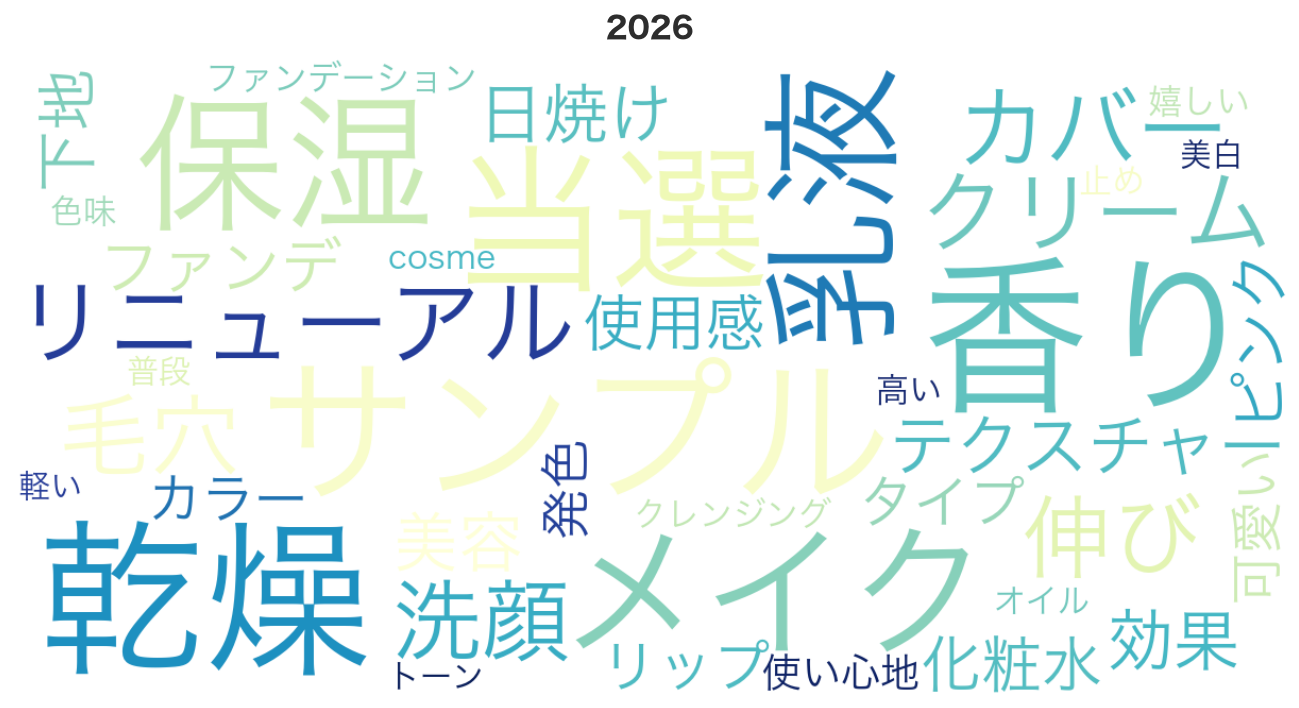

  wordcloud_2026.png  top 5: ['香り', '乾燥', '当選', 'サンプル', '保湿']

--- PRIVATE: Skincare-only ---
Saved → ../outputs/wordcloud_skincare_2019.png


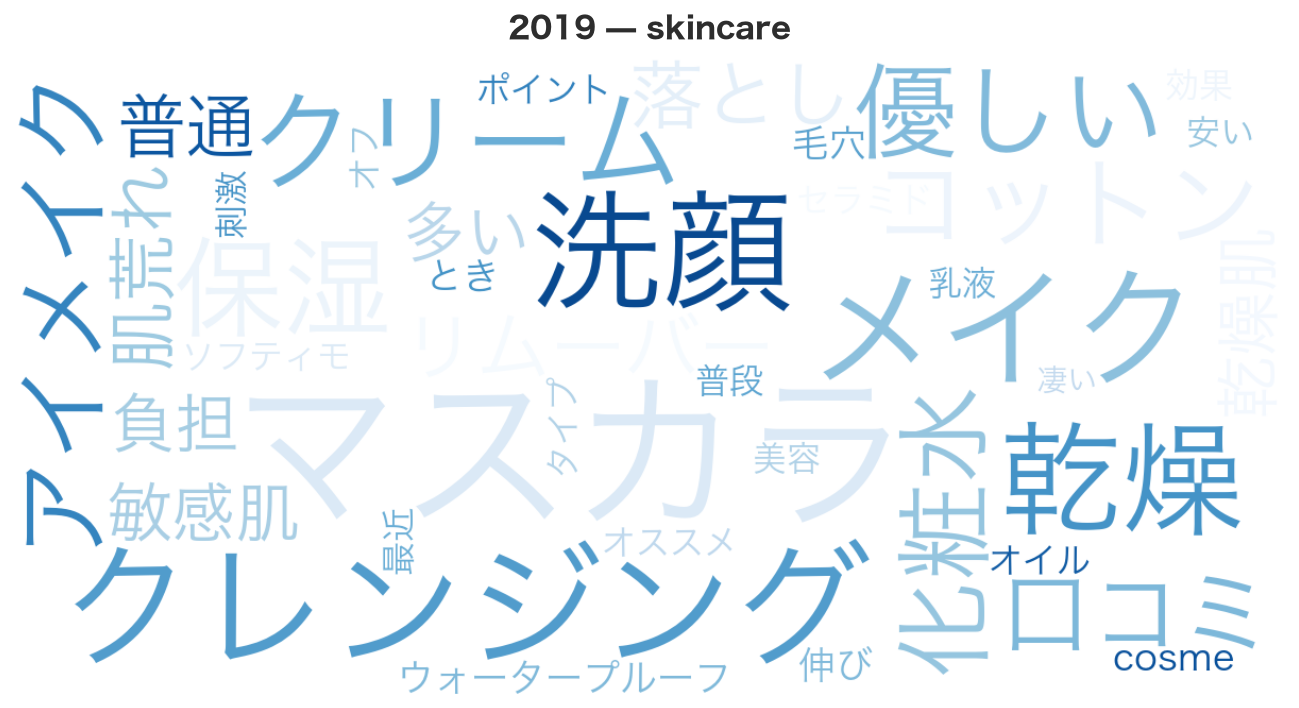

  wordcloud_skincare_2019.png  top 5: ['マスカラ', 'クレンジング', '洗顔', 'メイク', '乾燥']
Saved → ../outputs/wordcloud_skincare_2020.png


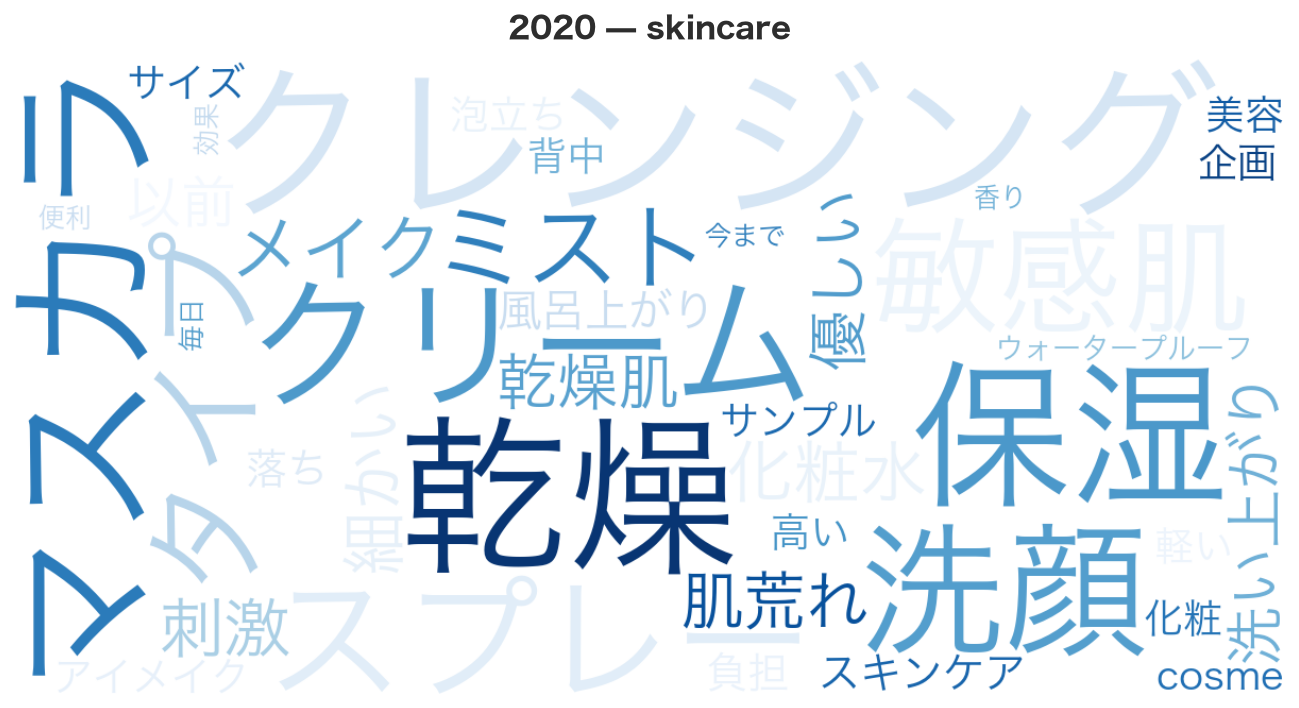

  wordcloud_skincare_2020.png  top 5: ['乾燥', 'クレンジング', '保湿', 'マスカラ', '洗顔']
Saved → ../outputs/wordcloud_skincare_2021.png


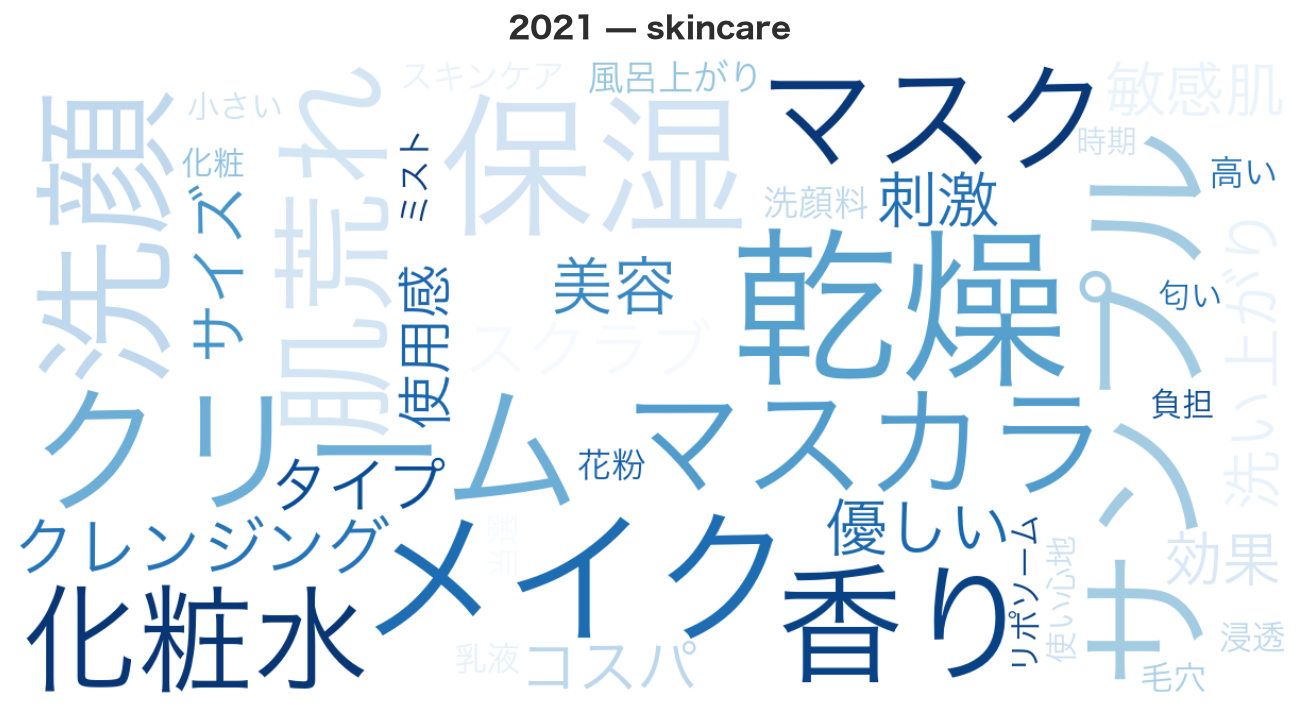

  wordcloud_skincare_2021.png  top 5: ['乾燥', '保湿', '洗顔', 'メイク', 'サンプル']
Saved → ../outputs/wordcloud_skincare_2022.png


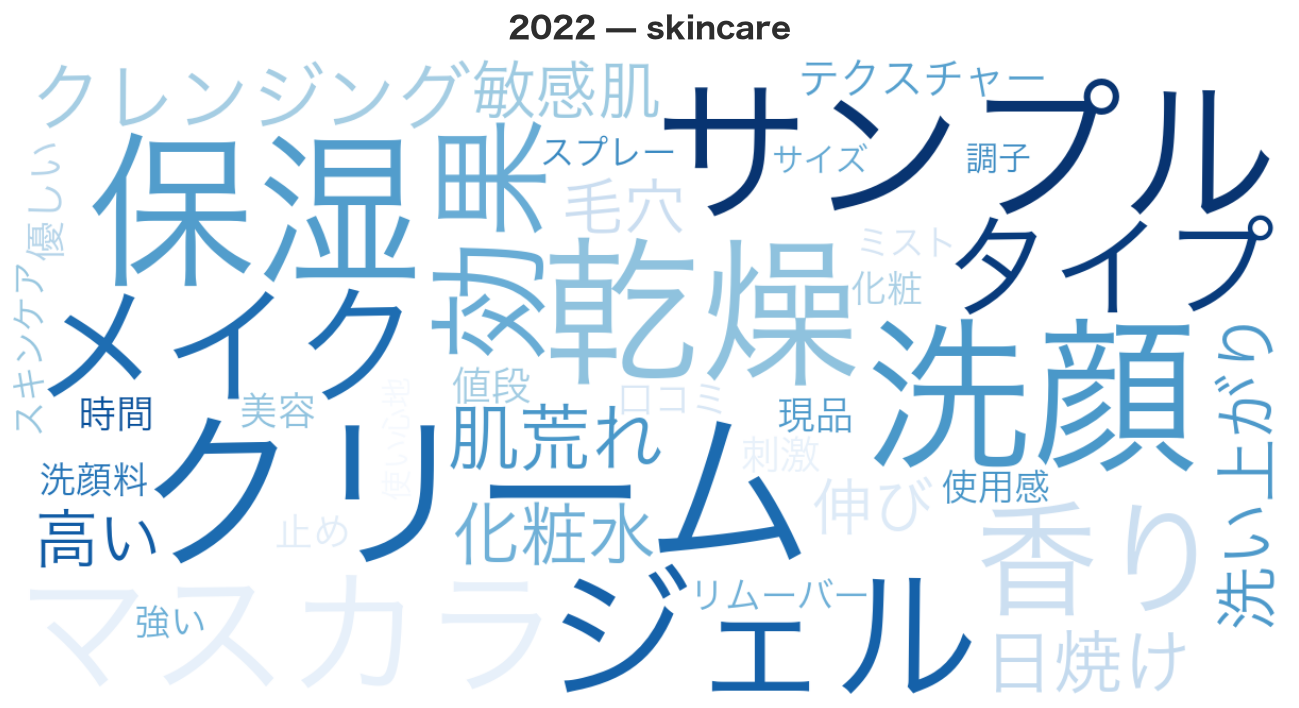

  wordcloud_skincare_2022.png  top 5: ['クリーム', '保湿', '洗顔', '乾燥', 'サンプル']
Saved → ../outputs/wordcloud_skincare_2023.png


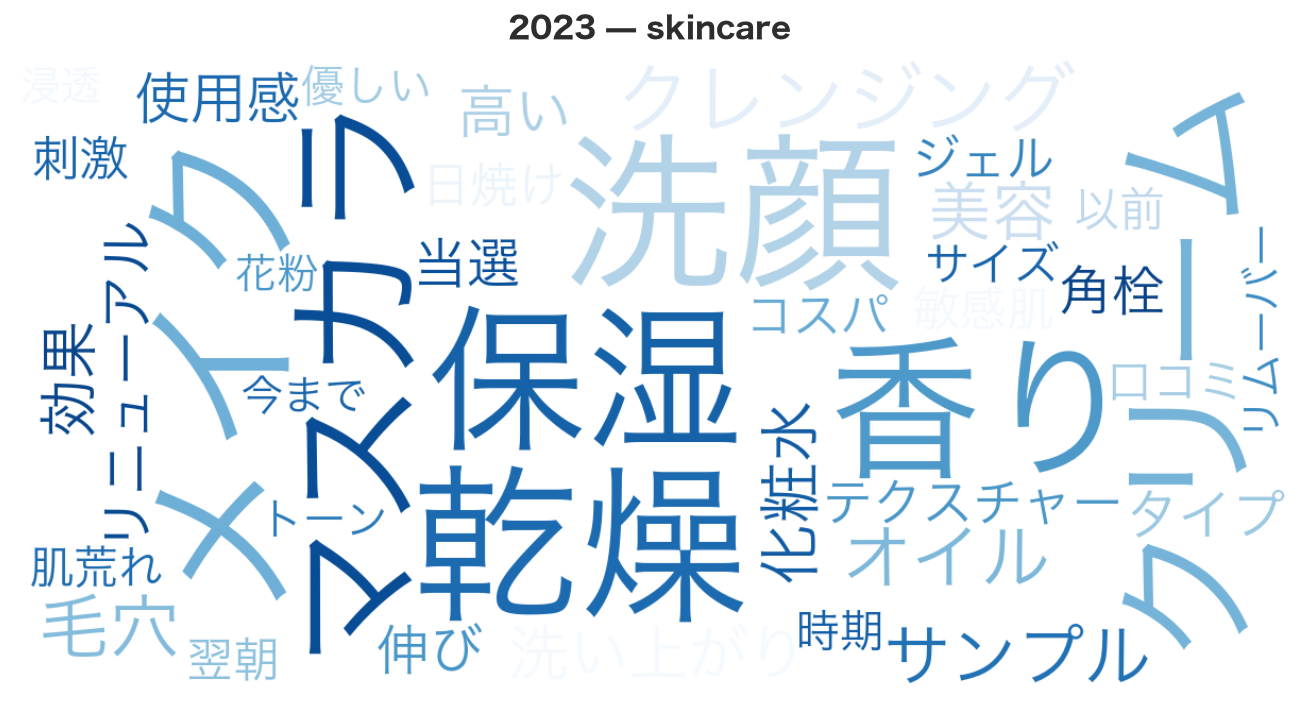

  wordcloud_skincare_2023.png  top 5: ['洗顔', '乾燥', 'メイク', '保湿', '香り']
Saved → ../outputs/wordcloud_skincare_2024.png


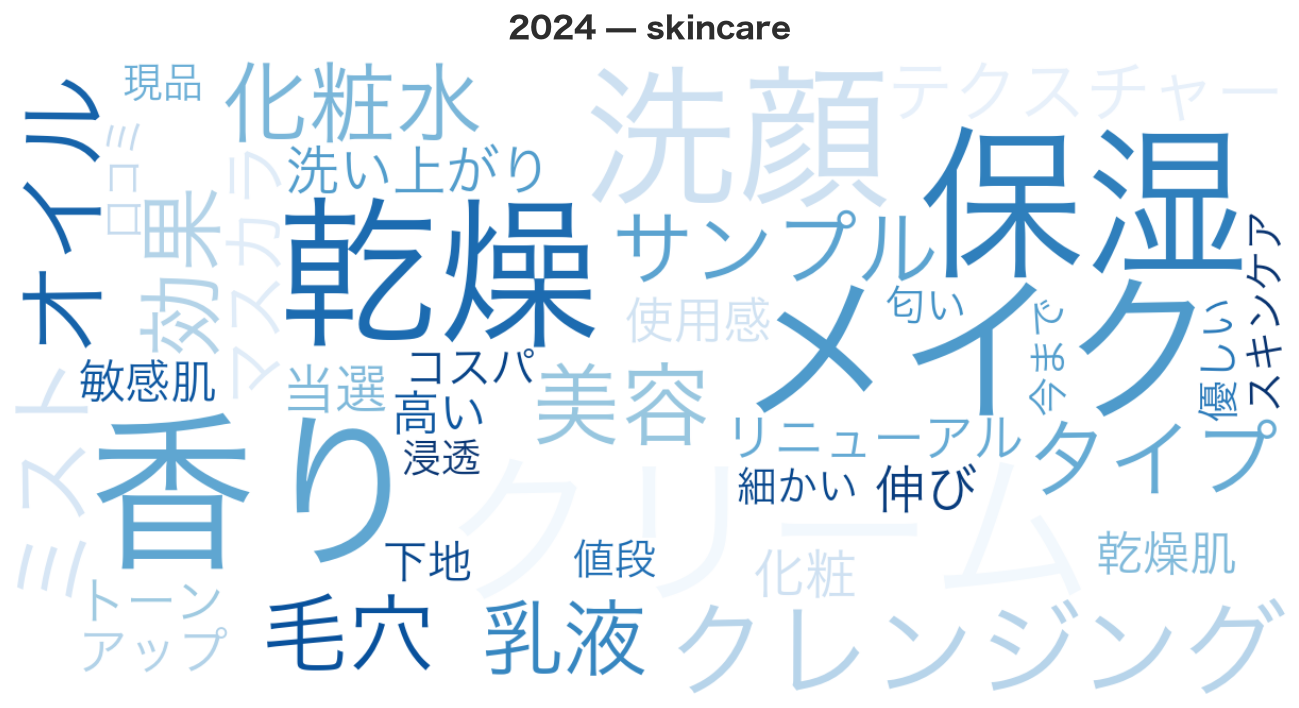

  wordcloud_skincare_2024.png  top 5: ['香り', '保湿', 'クリーム', '乾燥', 'メイク']
Saved → ../outputs/wordcloud_skincare_2025.png


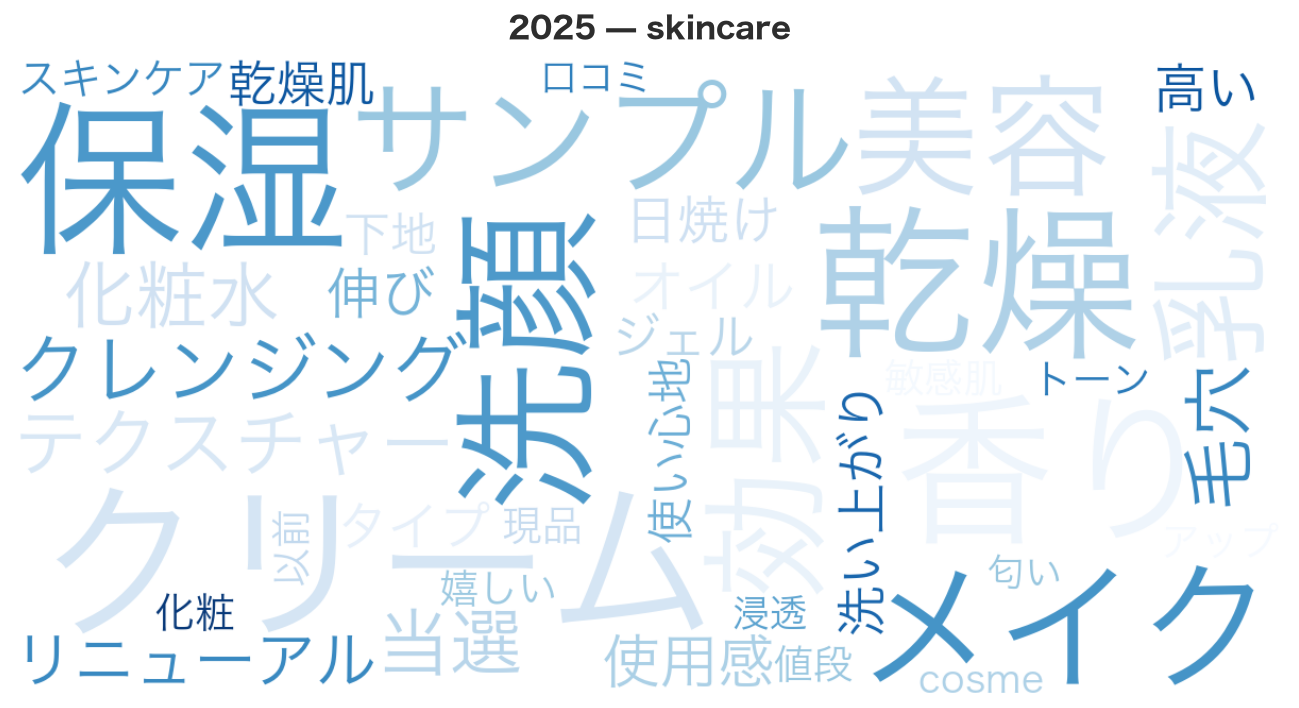

  wordcloud_skincare_2025.png  top 5: ['クリーム', '保湿', '乾燥', '香り', '洗顔']
Saved → ../outputs/wordcloud_skincare_2026.png


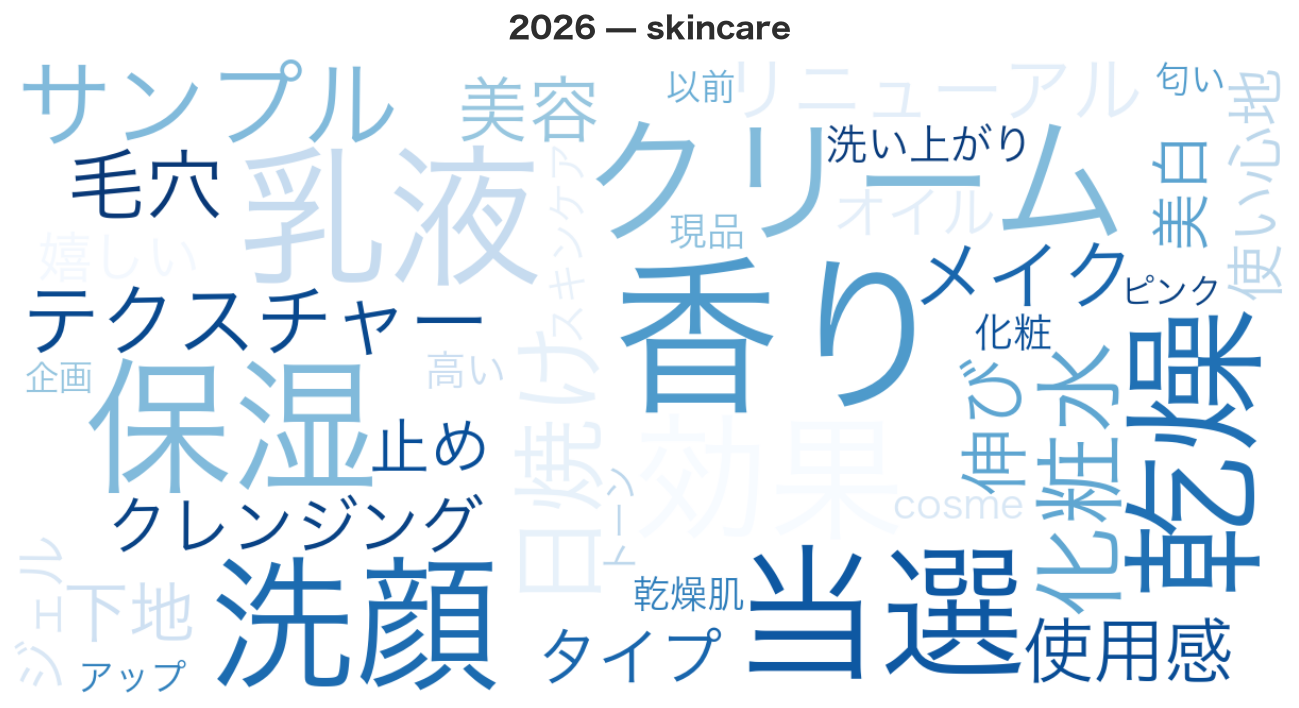

  wordcloud_skincare_2026.png  top 5: ['香り', '乳液', '保湿', '乾燥', '当選']

--- PRIVATE: Cosmetics-only ---
Saved → ../outputs/wordcloud_cosmetics_2021.png


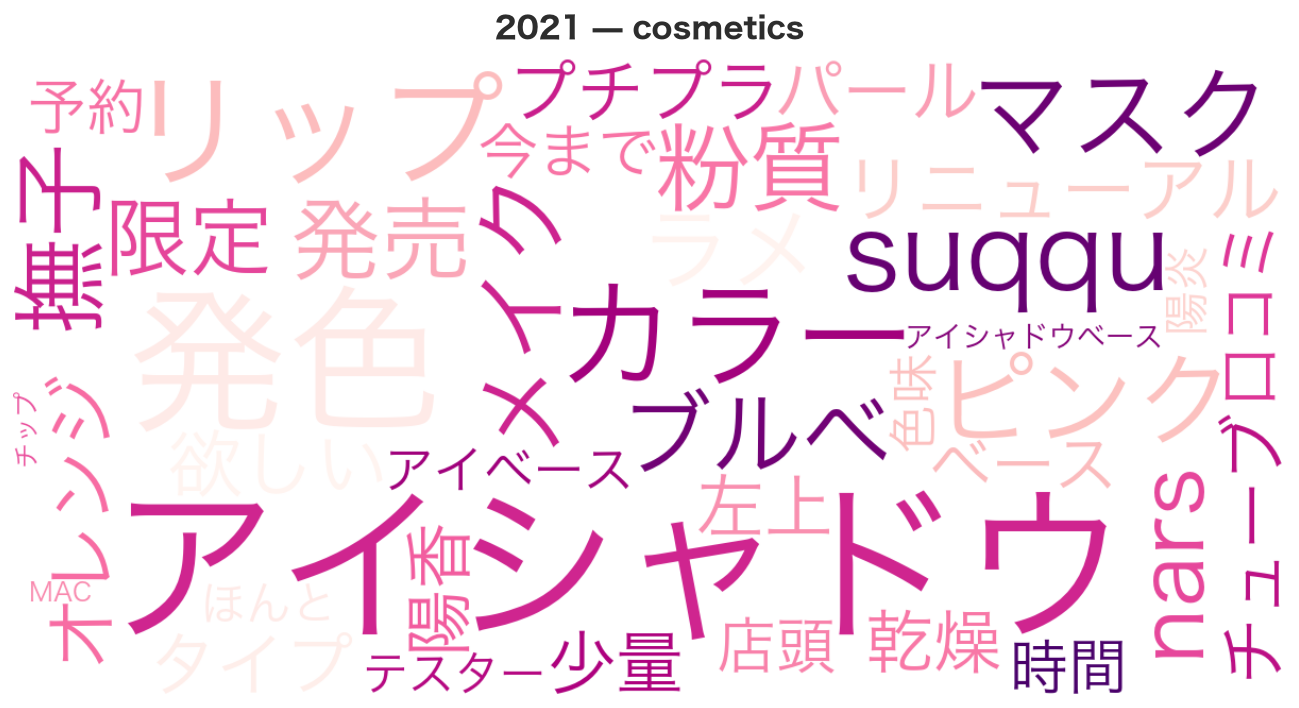

  wordcloud_cosmetics_2021.png  top 5: ['アイシャドウ', '発色', 'リップ', 'カラー', 'suqqu']
Saved → ../outputs/wordcloud_cosmetics_2022.png


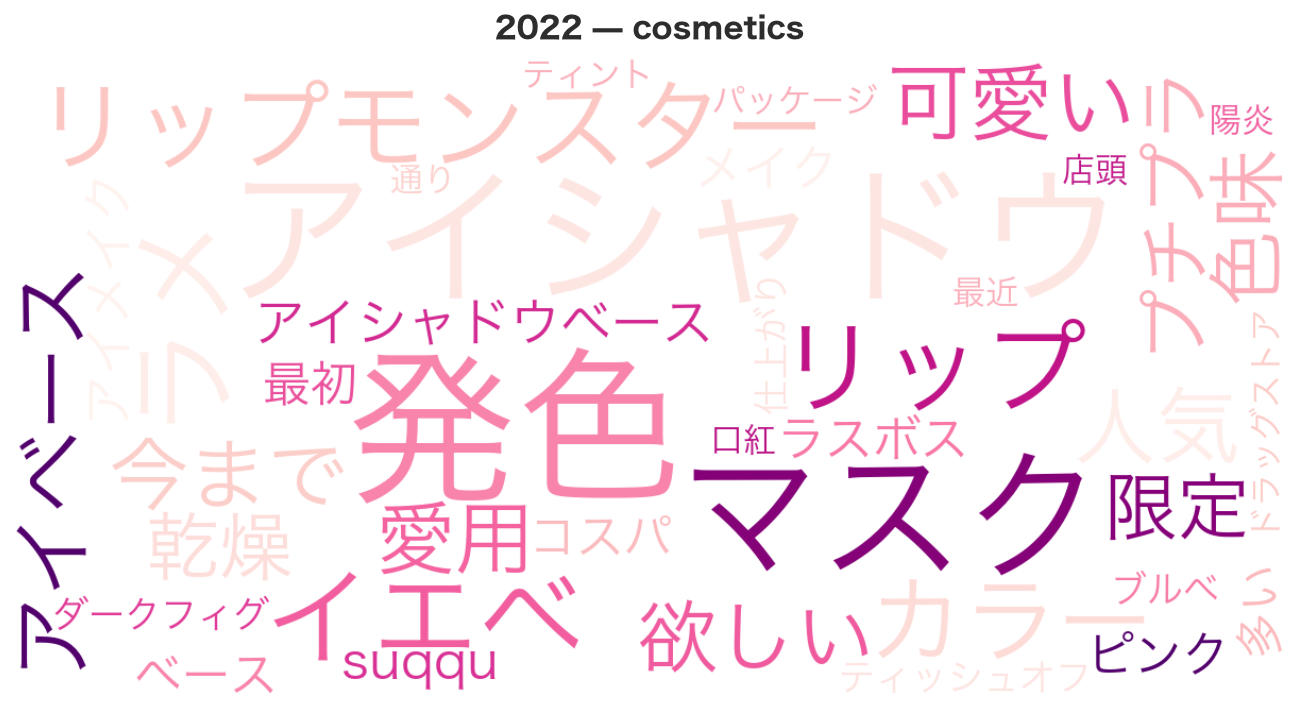

  wordcloud_cosmetics_2022.png  top 5: ['発色', 'アイシャドウ', 'マスク', 'ラメ', 'イエベ']
Saved → ../outputs/wordcloud_cosmetics_2023.png


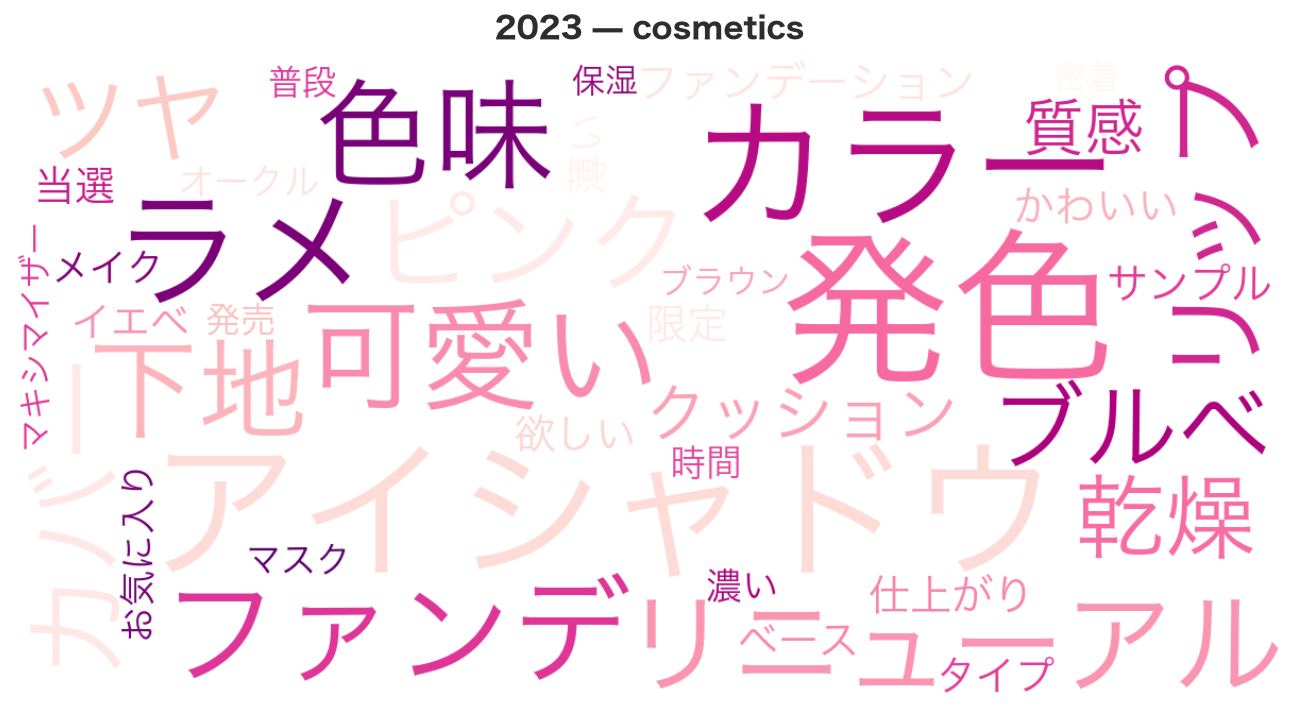

  wordcloud_cosmetics_2023.png  top 5: ['発色', 'アイシャドウ', 'カラー', 'ラメ', '可愛い']
Saved → ../outputs/wordcloud_cosmetics_2024.png


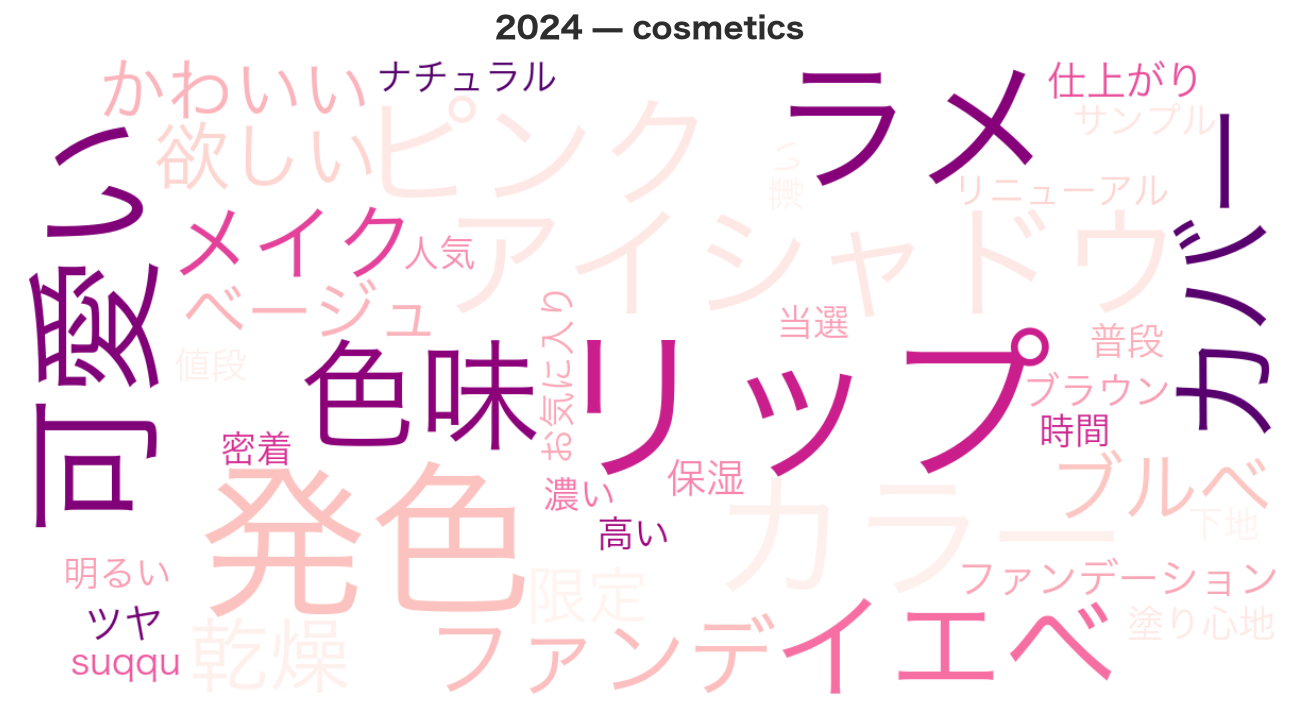

  wordcloud_cosmetics_2024.png  top 5: ['発色', 'リップ', 'ラメ', '可愛い', 'カラー']
Saved → ../outputs/wordcloud_cosmetics_2025.png


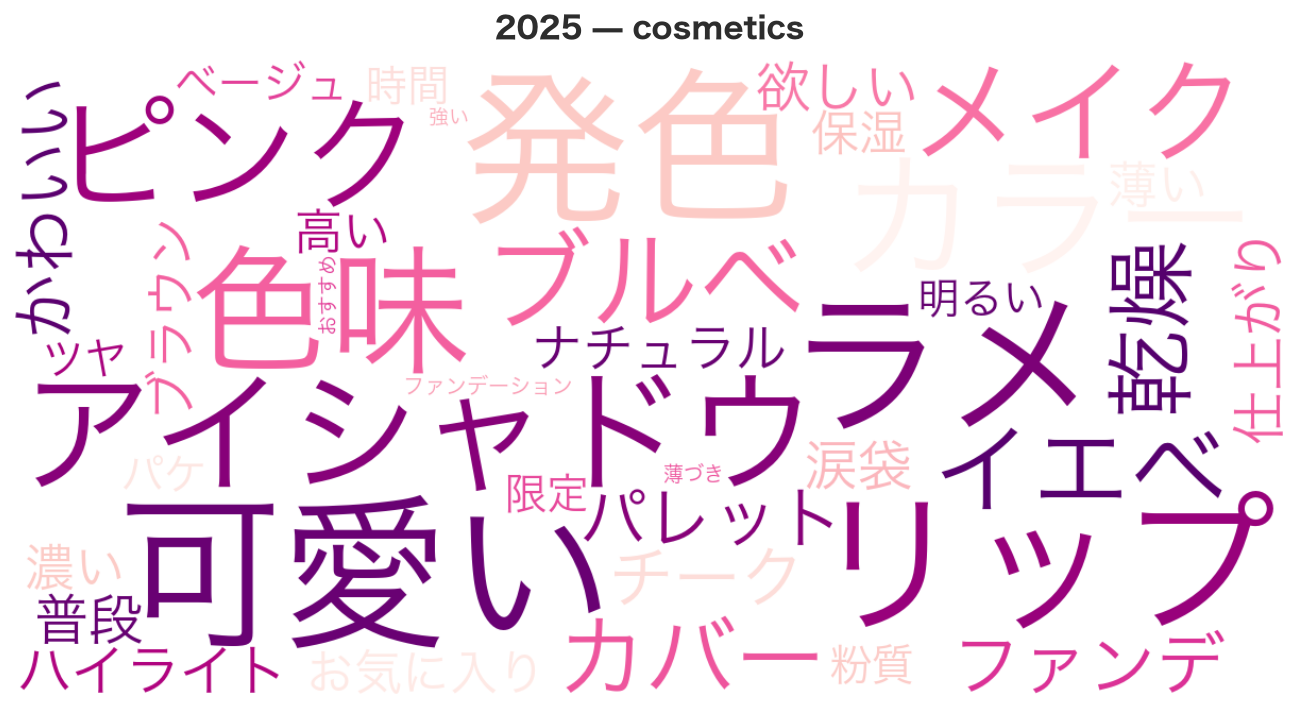

  wordcloud_cosmetics_2025.png  top 5: ['発色', '可愛い', 'ラメ', 'リップ', '色味']
Saved → ../outputs/wordcloud_cosmetics_2026.png


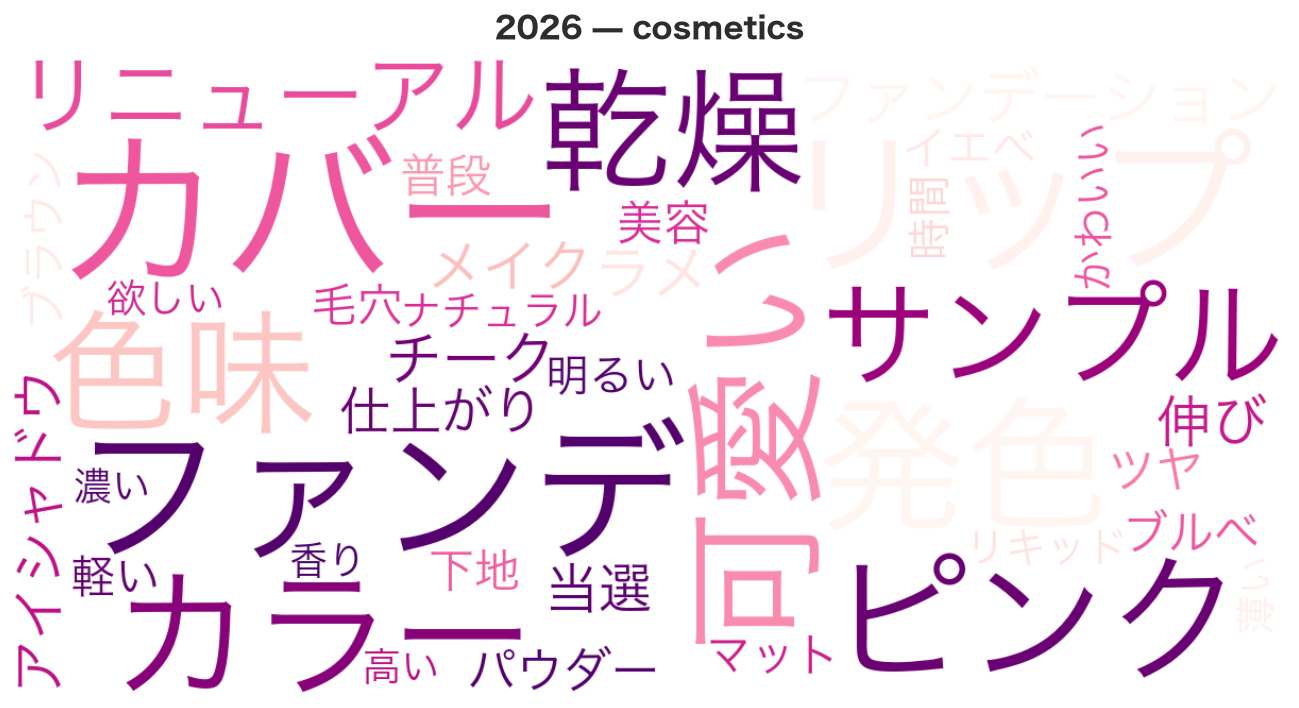

  wordcloud_cosmetics_2026.png  top 5: ['カバー', 'リップ', 'ファンデ', '発色', '可愛い']

Complete. 24 word clouds generated (latest year partial).


In [8]:
from wordcloud import WordCloud
from sudachipy import tokenizer as tokenizer_obj
from sudachipy import dictionary
from collections import Counter
import re

# ── Cross-platform Japanese font resolution ───────────────────────────────
def _find_jp_font():
    """Return first available Japanese font path, or None."""
    import platform
    candidates = []
    system = platform.system()
    if system == 'Windows':
        candidates = [
            r'C:\Windows\Fonts\msgothic.ttc',
            r'C:\Windows\Fonts\meiryo.ttc',
            r'C:\Windows\Fonts\YuGothR.ttc',
        ]
    elif system == 'Darwin':
        candidates = [
            '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc',
            '/System/Library/Fonts/Hiragino Sans GB.ttc',
            '/Library/Fonts/Arial Unicode.ttf',
        ]
    else:  # Linux / Streamlit Cloud
        candidates = [
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/OTF/NotoSansCJK-Regular.ttc',
        ]
    for path in candidates:
        if Path(path).exists():
            return path
    # Last resort: let matplotlib find one
    from matplotlib.font_manager import findfont, FontProperties
    fallback = findfont(FontProperties(family='sans-serif'))
    print(f'  ⚠ No CJK font found in candidates — falling back to: {fallback}')
    return fallback

FONT_PATH = _find_jp_font()
print(f'Font: {FONT_PATH}')

_tokenizer = dictionary.Dictionary().create()
_mode = tokenizer_obj.Tokenizer.SplitMode.C

# ── Brand names from brands.xlsx — suppress in word clouds ───────────────
BRAND_STOPWORDS = {
    'スック', 'アールエムケー', 'センサイ', 'カネボウ', 'エスト',
    'ソフィーナ', 'ケイト', 'フリープラス', 'キュレル', 'ルナソル',
    'アリィー', 'プリマヴィスタ', 'suisai', 'デュウ', 'エビータ',
    'ビオレ', 'ラロッシュポゼ', 'ヴィシー', 'メイベリン', 'ランコム',
    'シュウウエムラ', 'シュウ', 'ウエムラ', '資生堂', 'アネッサ',
    'クレドポー', 'ナーズ', 'イプサ', 'エリクシール', 'マキアージュ',
    'コーセー', 'デコルテ', '雪肌精', 'ヴィセ', '肌ラボ', 'メラノ',
    'セザンヌ', 'キャンメイク', 'エスティローダー', 'クリニーク',
    'ラメール', 'ボビイブラウン', 'トムフォード', 'ディオール',
    'ジバンシィ', 'ゲラン', 'ベネフィット', 'フレッシュ',
    'フェンティ', 'タカミ', 'キールズ', 'オルビス', 'アテニア',
    'ヒロインメイク', 'ヒロイン', 'ドクターケイ',
    # Korean brands
    'アヌア', 'コスアールエックス', 'メディキューブ', 'イニスフリー',
    'ラネージュ', 'クリオ', 'ミシャ',
}

# ── Generic stopwords ─────────────────────────────────────────────────────
STOPWORDS = {
    'する', 'いる', 'ある', 'なる', 'くる', 'いく', 'もの', 'こと',
    'ない', 'れる', 'られる', 'てる', 'です', 'ます', 'でし', 'まし',
    'これ', 'それ', 'あれ', 'この', 'その', 'あの',
    'とても', 'すごく', 'かなり', 'ちょっと', 'また', 'もう',
    'よく', 'さん', 'ちゃん', 'くん', 'におい', 'かな',
    'さらに', 'ほど', 'だけ', 'まま', 'ため', 'よう', 'くらい',
    '良い', 'いい', 'よい', 'すごい', 'ずごい',
    'リピート', 'リピ',
    '購入', '使用', '使い', '使う',
    '感じ', '感じる',
    '商品', 'コスメ', 'プレゼント',
    'ところ', 'アット', 'ほう',
    'こちら', 'そちら', 'あちら',
    'なんか', 'なんと', 'やっぱ', 'やはり',
    'ずっと', 'しっかり', 'しばらく',
    'ない', 'なく', 'なかっ',
    '自分', '今回', '今', '前', '本当',
    'あり', 'あっ', 'なり', 'いつも',
    'thought', 'use', 'the', 'and', 'for', 'fas',
}

ALL_STOPWORDS = STOPWORDS | BRAND_STOPWORDS

# Regex patterns to filter noise tokens
NOISE_PATTERNS = [
    r'^\d+$',               # pure numbers: 00, 01, 101
    r'^\d+[\.\d]*mm$',      # measurements: 0.1mm, 1.5mm
    r'^[\d\.]+$',           # decimals: 0.1, 4.5
    r'^[a-zA-Z]{1,2}$',     # single/double latin chars: mm, cc
    r'^\d+[a-zA-Z]+$',      # mixed: 2020, 3g
]

def is_noise(token):
    for pattern in NOISE_PATTERNS:
        if re.match(pattern, token, re.IGNORECASE):
            return True
    return False

def tokenize_text(text):
    if not text or not isinstance(text, str):
        return []
    morphemes = _tokenizer.tokenize(text, _mode)
    tokens = []
    for m in morphemes:
        pos = m.part_of_speech()[0]
        if pos not in ('名詞', '形容詞'):
            continue
        word = m.dictionary_form()
        if len(word) < 2:
            continue
        if word in ALL_STOPWORDS:
            continue
        if is_noise(word):
            continue
        tokens.append(word)
    return tokens

def make_wordcloud(freq, year, save_path, colormap='RdPu', title_suffix=''):
    # Require minimum frequency of 3 — kills one-off noise
    freq = {w: c for w, c in freq.items() if c >= 3}
    if len(freq) < 10:
        print(f'  WARNING: only {len(freq)} tokens after filtering for {year}')
        return

    wc = WordCloud(
        font_path=FONT_PATH,
        width=1200,
        height=600,
        background_color='white',
        max_words=40,           # fewer = each word larger = more readable
        colormap=colormap,
        prefer_horizontal=0.85,
        min_font_size=12,
        max_font_size=160,
        collocations=False,
    ).generate_from_frequencies(freq)

    fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{year}{title_suffix}',
                 fontsize=18, fontweight='bold',
                 color='#2D2D2D', pad=12)
    tight(fig, str(save_path), dpi=150)
    plt.show()
    top5 = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f'  {save_path.name}  top 5: {[w for w,_ in top5]}')

# ── Load and tokenize ─────────────────────────────────────────────────────
print('Loading reviews...')
df_reviews = pd.read_sql(f"""
    SELECT r.review_year, r.review_text,
           CASE WHEN {CANON} IN ({SKIN_TIERS})
                THEN 'skincare' ELSE 'cosmetics' END AS tier_group
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2019 AND 2026  -- latest year partial
      AND r.review_text IS NOT NULL
      AND c.normalized_name != 'beauty_all'
      AND {CANON} IN ({ALL_TIERS})
""", conn)
print(f'Reviews: {len(df_reviews):,}')

print('Tokenizing...')
df_reviews['tokens'] = df_reviews['review_text'].apply(tokenize_text)
print('Done.')

YEARS = list(range(2019, 2027))   # incl. partial 2026

# ── Generate: PUBLIC combined ─────────────────────────────────────────────
print('\n--- PUBLIC: Combined word clouds ---')
for year in YEARS:
    yr_tokens = [t for tokens in
                 df_reviews[df_reviews.review_year == year]['tokens']
                 for t in tokens]
    freq = Counter(yr_tokens)
    make_wordcloud(freq, year,
                   OUTPUTS / f'wordcloud_{year}.png',
                   colormap='YlGnBu')

# ── Generate: PRIVATE skincare ────────────────────────────────────────────
# NOTE: 2019–2023 skincare-only word clouds include miscategorised reviews
# (mascara comments tagged as skincare) and @cosme giveaway-template text.
# マスカラ/細い/まつ毛 appearing in skincare clouds pre-2024 is documented
# corpus noise, not a signal (LDA and HDBSCAN both isolate these; NB06).
print('\n--- PRIVATE: Skincare-only ---')
for year in YEARS:
    yr_tokens = [t for tokens in
                 df_reviews[(df_reviews.review_year == year) &
                             (df_reviews.tier_group == 'skincare')]['tokens']
                 for t in tokens]
    freq = Counter(yr_tokens)
    make_wordcloud(freq, year,
                   OUTPUTS / f'wordcloud_skincare_{year}.png',
                   colormap='Blues',
                   title_suffix=' — skincare')

# ── Generate: PRIVATE cosmetics ───────────────────────────────────────────
print('\n--- PRIVATE: Cosmetics-only ---')
for year in YEARS:
    yr_tokens = [t for tokens in
                 df_reviews[(df_reviews.review_year == year) &
                             (df_reviews.tier_group == 'cosmetics')]['tokens']
                 for t in tokens]
    freq = Counter(yr_tokens)
    make_wordcloud(freq, year,
                   OUTPUTS / f'wordcloud_cosmetics_{year}.png',
                   colormap='RdPu',
                   title_suffix=' — cosmetics')

print('\n' + '=' * 55)
print('Complete. 24 word clouds generated (latest year partial).')

In [9]:
# ── Auto-copy word clouds to dashboard/assets/ ────────────────────────────
import shutil
DASHBOARD_ASSETS = Path('../dashboard/assets')
print('\nCopying word clouds to dashboard/assets/...')
for year in YEARS:
    src = OUTPUTS / f'wordcloud_{year}.png'
    if src.exists():
        shutil.copy2(src, DASHBOARD_ASSETS / f'wordcloud_{year}.png')
        print(f'  ✓  wordcloud_{year}.png')
print('Done.')


Copying word clouds to dashboard/assets/...
  ✓  wordcloud_2019.png
  ✓  wordcloud_2020.png
  ✓  wordcloud_2021.png
  ✓  wordcloud_2022.png
  ✓  wordcloud_2023.png
  ✓  wordcloud_2024.png
  ✓  wordcloud_2025.png
  ✓  wordcloud_2026.png
Done.


## CELL 2B (markdown)

### Finding 2 — The language changed

The word clouds are a qualitative illustration of consumer vocabulary, not a
quantitative read. @cosme's category mix varies by year — the pre-2020 corpus is
small and skincare-heavy (NB06) — so cross-year word-cloud comparison reflects
composition as much as language. The makeup terms (マスカラ, まつ毛) in the
pre-2024 skincare clouds are documented miscategorisation noise, not signal (see
the note in the word-cloud cell).

The defensible, quantitative reads are the size-matched cosine and Google Trends.
The raw full-data cosine rise is largely a sample-size artifact; once corpus
slices are equalised in size, a small but real convergence remains (**Δ ≈ +0.065**,
NB06 §2). Skincare and cosmetics review vocabulary are drifting slowly closer,
not merging.

## CELL 2C (code) — Display NB06 language assets

Saved → ../outputs/nb07_language.png


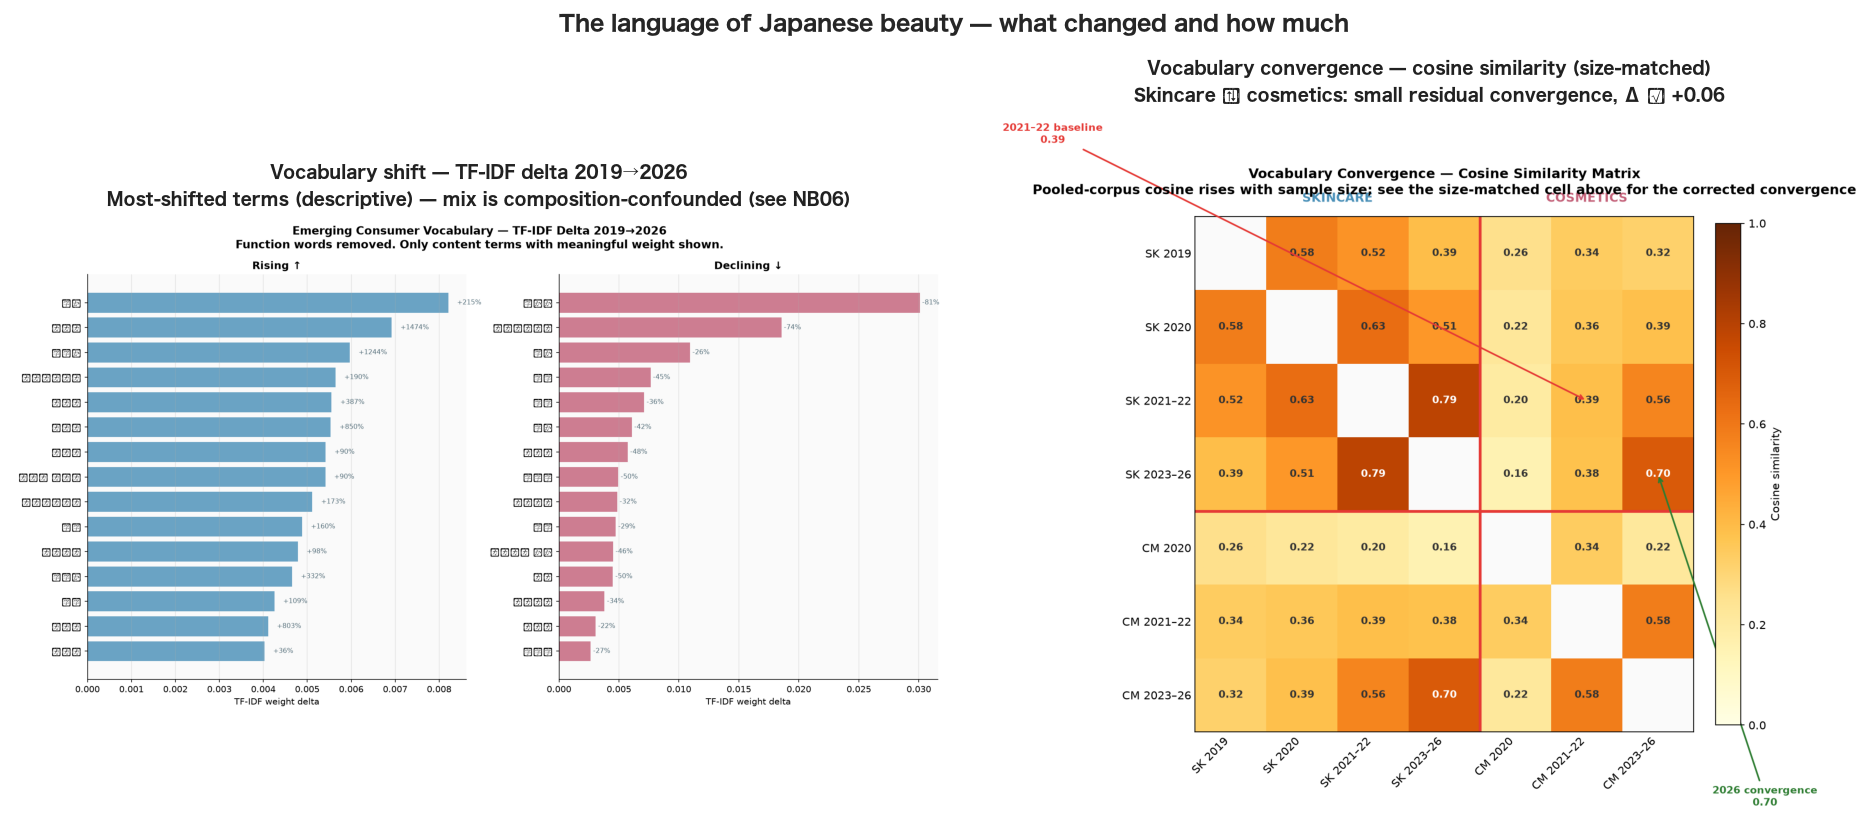

In [10]:
# ── Display cosine similarity + emerging terms from NB06 ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

for ax, fname, title in [
    (axes[0], 'nb06_emerging_terms.png',
     'Vocabulary shift — TF-IDF delta 2019→2026\n'
     'Most-shifted terms (descriptive) — mix is composition-confounded (see NB06)'),
    (axes[1], 'nb06_cosine_similarity.png',
     'Vocabulary convergence — cosine similarity (size-matched)\n'
     'Skincare ↔ cosmetics: small residual convergence, Δ ≈ +0.065'),
]:
    p = OUTPUTS / fname
    if p.exists():
        ax.imshow(imread(str(p)))
        ax.axis('off')
        ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

fig.suptitle('The language of Japanese beauty — what changed and how much',
             fontsize=13, fontweight='bold')
plt.tight_layout()
tight(fig, str(OUTPUTS / 'nb07_language.png'))
plt.show()

In [11]:
# ── Verify YouTube assets — produced by NB06 Section 6 Cell 33 ───────────
# NB06 owns YouTube export logic (correct category mapping, 2019–2026 range).
# NB06 Cell 38 copies them to dashboard/assets/.
# This cell just confirms the files are present and non-empty.

import shutil
from pathlib import Path as _P

DASHBOARD_ASSETS = _P('../dashboard/assets')
OUTPUTS_DIR = OUTPUTS

yt_assets = [
    'nb07_yt_volume.csv',
    'nb07_yt_channels.csv',
    'nb07_yt_tfidf.csv',
]

print("YouTube CSV verification:")
all_ok = True
for fname in yt_assets:
    asset_path = DASHBOARD_ASSETS / fname
    out_path   = OUTPUTS_DIR / fname
    if asset_path.exists():
        rows = sum(1 for _ in open(asset_path, encoding='utf-8-sig')) - 1
        # Mirror to outputs/ for consistency
        shutil.copy2(asset_path, out_path)
        print(f"  ✓  {fname}  ({rows} data rows)")
    else:
        print(f"  ✗  {fname}  — MISSING. Re-run NB06 Section 6.")
        all_ok = False

print()
if all_ok:
    print("All YouTube assets present. Dashboard ready.")
else:
    print("Re-run NB06 Sections 6 and 8 (auto-copy) to generate missing files.")


YouTube CSV verification:
  ✓  nb07_yt_volume.csv  (15 data rows)
  ✓  nb07_yt_channels.csv  (145 data rows)
  ✓  nb07_yt_tfidf.csv  (60 data rows)

All YouTube assets present. Dashboard ready.


In [12]:
conn.close()
print()
print('=' * 60)
print('NB07 — Signal/Pulse: Executive Synthesis: COMPLETE')
print('=' * 60)
print()
print('GENERATED OUTPUTS:')
all_out = [
    # Section 1
    'nb07_trends_crossover.csv',
    'nb07_ingredient_surge.csv',
    'nb07_sku_treemap.csv',
    'nb07_review_slope.csv',
    'nb07_makeup_rebound.csv',
    # Section 2
    'wordcloud_2019.png', 'wordcloud_2020.png', 'wordcloud_2021.png',
    'wordcloud_2022.png', 'wordcloud_2023.png', 'wordcloud_2024.png',
    'wordcloud_2025.png', 'wordcloud_2026.png',
    'nb07_language.png',
    # YouTube (verified from NB06)
    'nb07_yt_volume.csv', 'nb07_yt_channels.csv', 'nb07_yt_tfidf.csv',
]
for f in all_out:
    p = OUTPUTS / f
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'  [{status}]  {f}')
print()
print('Next: streamlit run dashboard/streamlit_app.py')



NB07 — Signal/Pulse: Executive Synthesis: COMPLETE

GENERATED OUTPUTS:
  [✓]  nb07_trends_crossover.csv
  [✓]  nb07_ingredient_surge.csv
  [✓]  nb07_sku_treemap.csv
  [✓]  nb07_review_slope.csv
  [✓]  nb07_makeup_rebound.csv
  [✓]  wordcloud_2019.png
  [✓]  wordcloud_2020.png
  [✓]  wordcloud_2021.png
  [✓]  wordcloud_2022.png
  [✓]  wordcloud_2023.png
  [✓]  wordcloud_2024.png
  [✓]  wordcloud_2025.png
  [✓]  wordcloud_2026.png
  [✓]  nb07_language.png
  [✓]  nb07_yt_volume.csv
  [✓]  nb07_yt_channels.csv
  [✓]  nb07_yt_tfidf.csv

Next: streamlit run dashboard/streamlit_app.py
